In [7]:
pip install pandas numpy matplotlib tqdm tabulate

Note: you may need to restart the kernel to use updated packages.


Training data from 2013/01/30 to 2018/07/12
Testing data from 2018/07/13 to 2023/12/29


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [19:06<00:00,  1.15s/it]


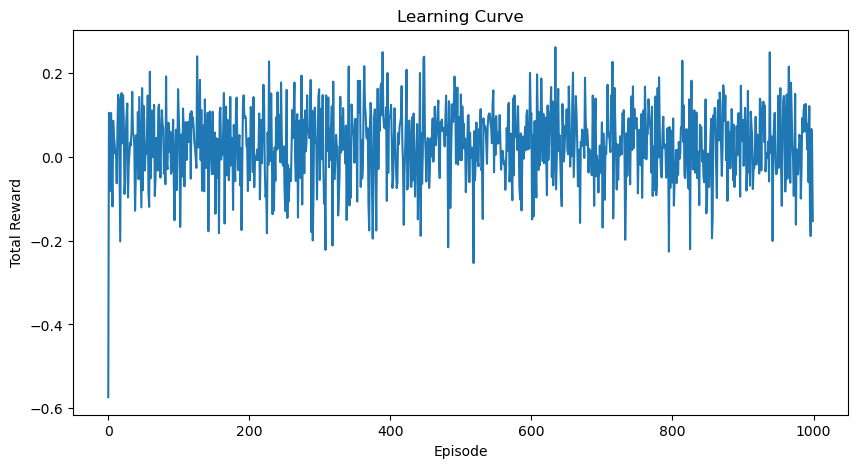


Performance Metrics:
Total Return (%): -84.7746
Annualized Return (%): -29.9032
Sharpe Ratio: -1.7844
Max Drawdown (%): 85.2965
Win Rate (%): 33.5581


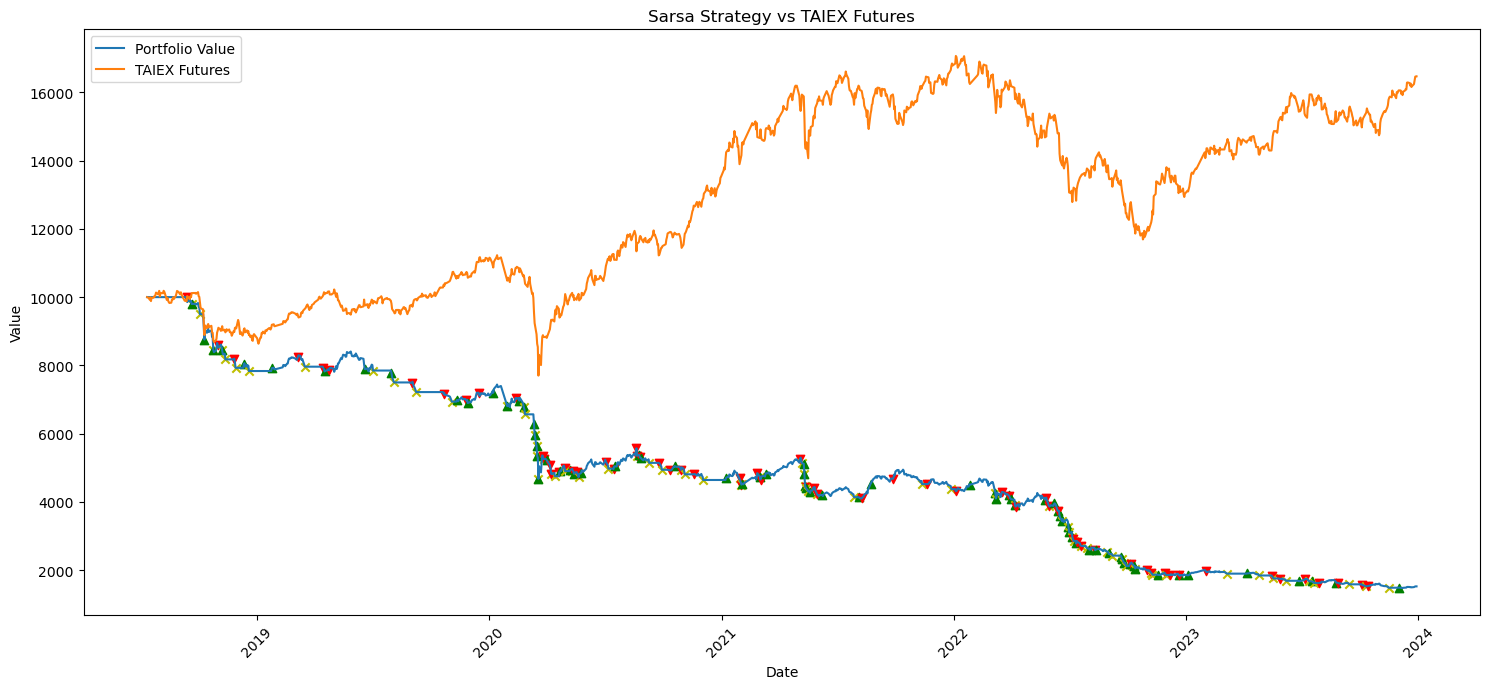

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

class SarsaAgent:
    def __init__(self, actions, epsilon=0.1, alpha=0.2, gamma=0.9):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    df['Return'] = df['Close'].pct_change()
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA5_slope'] = (df['MA5'] - df['MA5'].shift(1)) / df['MA5'].shift(1)
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(1)) / df['MA20'].shift(1)
    df['Volatility'] = df['Return'].rolling(window=20).std() * np.sqrt(252)
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row):
    ma5_trend = "Up" if row['MA5_slope'] > 0 else "Down"
    ma20_trend = "Up" if row['MA20_slope'] > 0 else "Down"
    vol_state = "High" if row['Volatility'] > 0.2 else "Low" if row['Volatility'] < 0.1 else "Medium"
    rsi_state = "OverBought" if row['RSI'] > 70 else "OverSold" if row['RSI'] < 30 else "Normal"
    macd_state = "Bullish" if row['MACD'] > row['Signal'] else "Bearish"
    return f"{ma5_trend}_{ma20_trend}_{vol_state}_{rsi_state}_{macd_state}"

def calculate_reward(action, return_value, position, consecutive_trades):
    base_reward = return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    consecutive_penalty = -0.001 * consecutive_trades
    return base_reward + consecutive_penalty

def run_sarsa(data, episodes=1000):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"])
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0])
        action = agent.get_action(state)
        consecutive_trades = 0
        episode_reward = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action != "Hold":
                consecutive_trades += 1
            else:
                consecutive_trades = 0
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, consecutive_trades)
            episode_reward += reward
            
            next_state = define_state(row)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
    
    return agent, rewards_history

def evaluate_strategy(agent, data, initial_capital=10000, stop_loss=0.02):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.get_action(state)
        return_value = row['Return']
        
        # 检查止损
        if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['Low']))
        elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['High']))
        
        if action == "Buy" and position != "Long":
            position = "Long"
            entry_price = row['Close']
            trades.append(("Buy", row.name, row['Close']))
        elif action == "Sell" and position != "Short":
            position = "Short"
            entry_price = row['Close']
            trades.append(("Sell", row.name, row['Close']))
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

# 主程序
file_path = "TX_daily.csv"
data = preprocess_data(file_path)

if data is not None:
    # 将数据分为训练集和测试集，比例为1:1
    train_size = len(data) // 2
    train_data = data[:train_size]
    test_data = data[train_size:]

    print(f"Training data from {train_data.index[0].strftime('%Y/%m/%d')} to {train_data.index[-1].strftime('%Y/%m/%d')}")
    print(f"Testing data from {test_data.index[0].strftime('%Y/%m/%d')} to {test_data.index[-1].strftime('%Y/%m/%d')}")

    trained_agent, rewards_history = run_sarsa(train_data, episodes=1000)
    
    plot_learning_curve(rewards_history)
    
    portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
    
    benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
    metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
    
    print("\nPerformance Metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")
    
    plot_results(test_data, portfolio_values, trades)
else:
    print("Failed to read or preprocess the data.")

In [11]:
def preprocess_data(file_path):
    """
    Enhanced data preprocessing function with proper handling of missing values,
    outliers, and feature normalization.
    """
    print("Starting data preprocessing...")
    
    # 讀取數據
    df = pd.read_csv(file_path, thousands=',')
    print(f"Loaded {len(df)} rows of data")
    
    # 處理日期
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 檢查並處理缺失值
    missing_values = df.isnull().sum()
    if missing_values.any():
        print("Found missing values. Handling them...")
        # 對於價格數據，使用前一個有效值填充
        price_columns = ['Open', 'High', 'Low', 'Close']
        df[price_columns] = df[price_columns].fillna(method='ffill')
    
    # 計算基本特徵
    df['Return'] = df['Close'].pct_change()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    
    # 計算移動平均
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA5_slope'] = (df['MA5'] - df['MA5'].shift(1)) / df['MA5'].shift(1)
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(1)) / df['MA20'].shift(1)
    
    # 計算技術指標
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    # 計算波動率
    df['Volatility'] = df['Return'].rolling(window=20).std() * np.sqrt(252)
    
    # 處理極端值
    for col in ['Return', 'Momentum', 'MA5_slope', 'MA20_slope']:
        # 計算分位數
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 設定上下界
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        # 將極端值設為邊界值
        df[col] = df[col].clip(lower_bound, upper_bound)
    
    # 特徵標準化
    features_to_normalize = ['Return', 'Momentum', 'MA5_slope', 'MA20_slope', 
                           'RSI', 'MACD', 'Signal', 'Volatility']
    
    # 使用滾動窗口進行標準化
    window_size = 60
    for feature in features_to_normalize:
        # 創建滾動窗口的平均值和標準差
        rolling_mean = df[feature].rolling(window=window_size).mean()
        rolling_std = df[feature].rolling(window=window_size).std()
        
        # 使用滾動標準化
        df[f'{feature}_norm'] = (df[feature] - rolling_mean) / rolling_std
        
        # 處理開始期間的NaN值
        df[f'{feature}_norm'].fillna(0, inplace=True)
    
    # 移除含有NaN的行
    df = df.dropna()
    print(f"Preprocessing complete. Final dataframe has {len(df)} rows")
    
    # 顯示數據基本統計信息
    print("\nFeature statistics after preprocessing:")
    print(df[[col for col in df.columns if '_norm' in col]].describe())
    
    return df

Training data from 2013/01/30 to 2018/07/12
Testing data from 2018/07/13 to 2023/12/29


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [04:44<00:00,  3.52it/s]


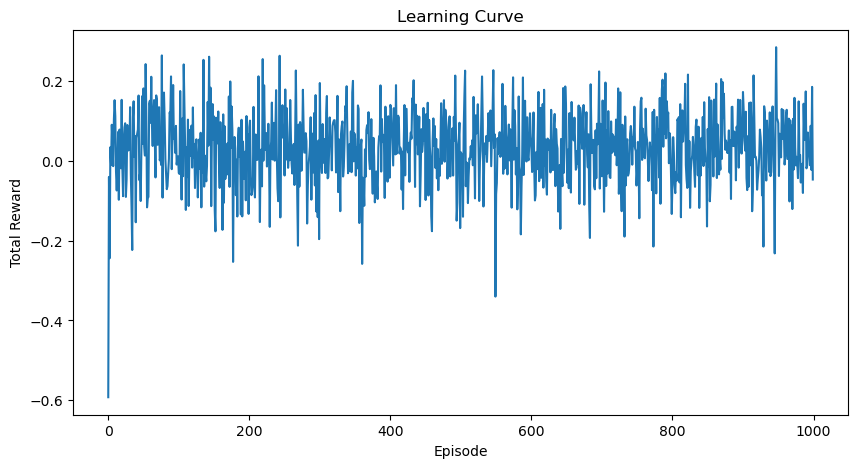


Performance Metrics:
Total Return (%): -45.5378
Annualized Return (%): -10.8371
Sharpe Ratio: -0.5584
Max Drawdown (%): 53.3600
Win Rate (%): 36.5543


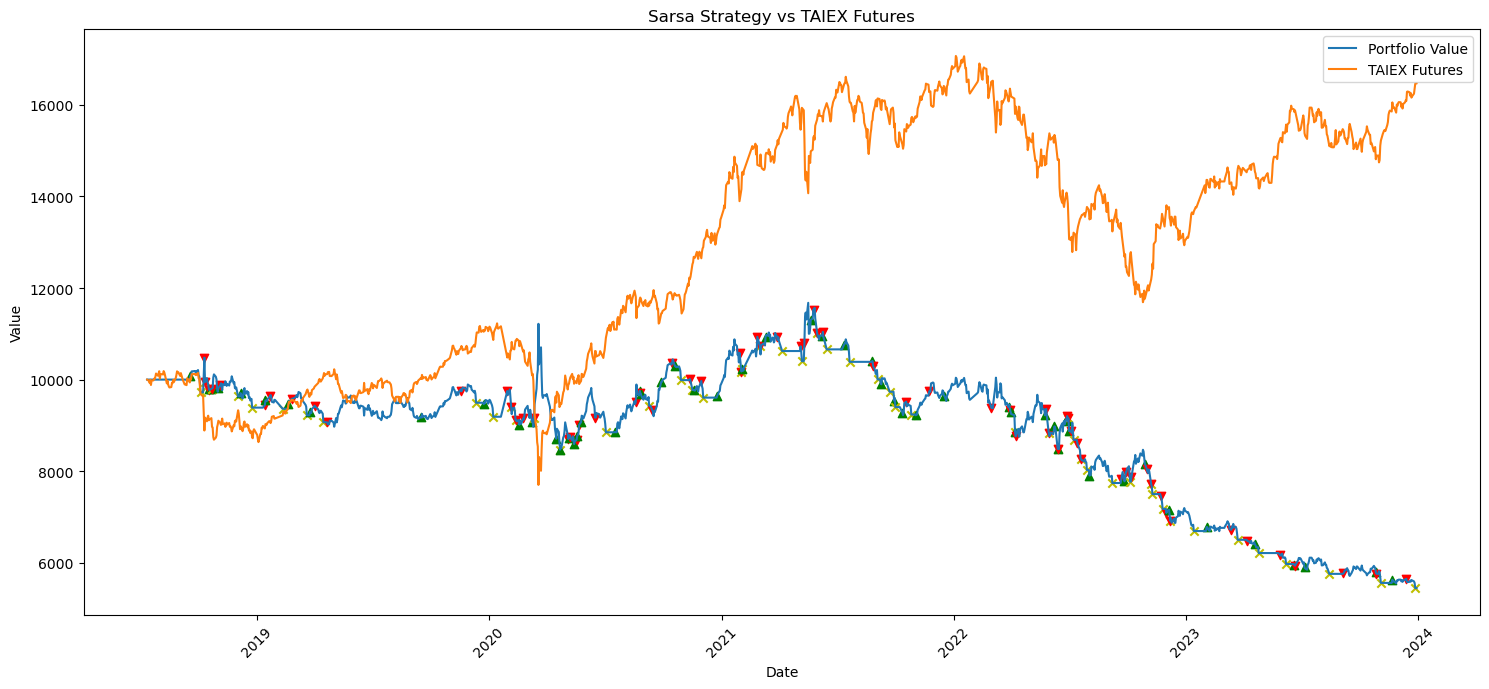

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

class SarsaAgent:
    def __init__(self, actions, epsilon=0.1, alpha=0.2, gamma=0.9):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    df['Return'] = df['Close'].pct_change()
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA5_slope'] = (df['MA5'] - df['MA5'].shift(1)) / df['MA5'].shift(1)
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(1)) / df['MA20'].shift(1)
    df['Volatility'] = df['Return'].rolling(window=20).std() * np.sqrt(252)
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row):
    ma5_trend = "Up" if row['MA5_slope'] > 0 else "Down"
    ma20_trend = "Up" if row['MA20_slope'] > 0 else "Down"
    vol_state = "High" if row['Volatility'] > 0.2 else "Low" if row['Volatility'] < 0.1 else "Medium"
    rsi_state = "OverBought" if row['RSI'] > 70 else "OverSold" if row['RSI'] < 30 else "Normal"
    macd_state = "Bullish" if row['MACD'] > row['Signal'] else "Bearish"
    return f"{ma5_trend}_{ma20_trend}_{vol_state}_{rsi_state}_{macd_state}"

def calculate_reward(action, return_value, position, consecutive_trades):
    base_reward = return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    consecutive_penalty = -0.001 * consecutive_trades
    return base_reward + consecutive_penalty

def run_sarsa(data, episodes=1000):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"])
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0])
        action = agent.get_action(state)
        consecutive_trades = 0
        episode_reward = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action != "Hold":
                consecutive_trades += 1
            else:
                consecutive_trades = 0
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, consecutive_trades)
            episode_reward += reward
            
            next_state = define_state(row)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
    
    return agent, rewards_history

def evaluate_strategy(agent, data, initial_capital=10000, stop_loss=0.02):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.get_action(state)
        return_value = row['Return']
        
        # 检查止损
        if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['Low']))
        elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['High']))
        
        if action == "Buy" and position != "Long":
            position = "Long"
            entry_price = row['Close']
            trades.append(("Buy", row.name, row['Close']))
        elif action == "Sell" and position != "Short":
            position = "Short"
            entry_price = row['Close']
            trades.append(("Sell", row.name, row['Close']))
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

# 主程序
file_path = "TX_daily.csv"
data = preprocess_data(file_path)

if data is not None:
    # 将数据分为训练集和测试集，比例为1:1
    train_size = len(data) // 2
    train_data = data[:train_size]
    test_data = data[train_size:]

    print(f"Training data from {train_data.index[0].strftime('%Y/%m/%d')} to {train_data.index[-1].strftime('%Y/%m/%d')}")
    print(f"Testing data from {test_data.index[0].strftime('%Y/%m/%d')} to {test_data.index[-1].strftime('%Y/%m/%d')}")

    trained_agent, rewards_history = run_sarsa(train_data, episodes=1000)
    
    plot_learning_curve(rewards_history)
    
    portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
    
    benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
    metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
    
    print("\nPerformance Metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")
    
    plot_results(test_data, portfolio_values, trades)
else:
    print("Failed to read or preprocess the data.")

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Optimized MA slope threshold: 0.5687
Optimized RSI threshold: 50.4601


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [03:48<00:00,  4.37it/s]


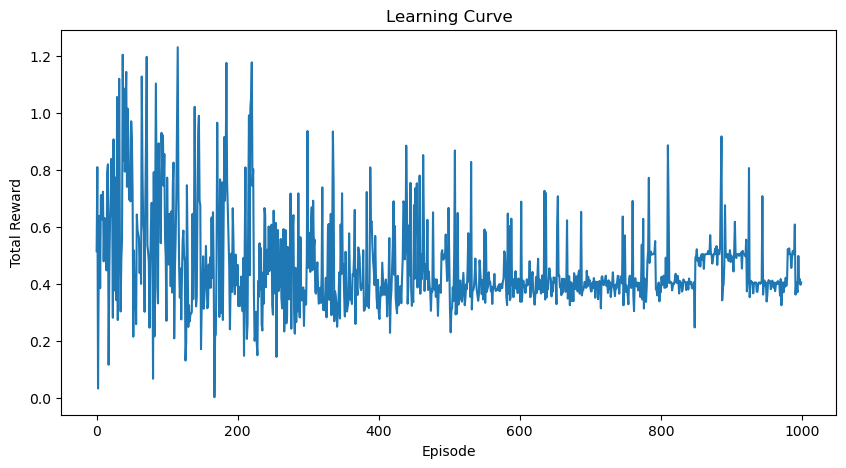

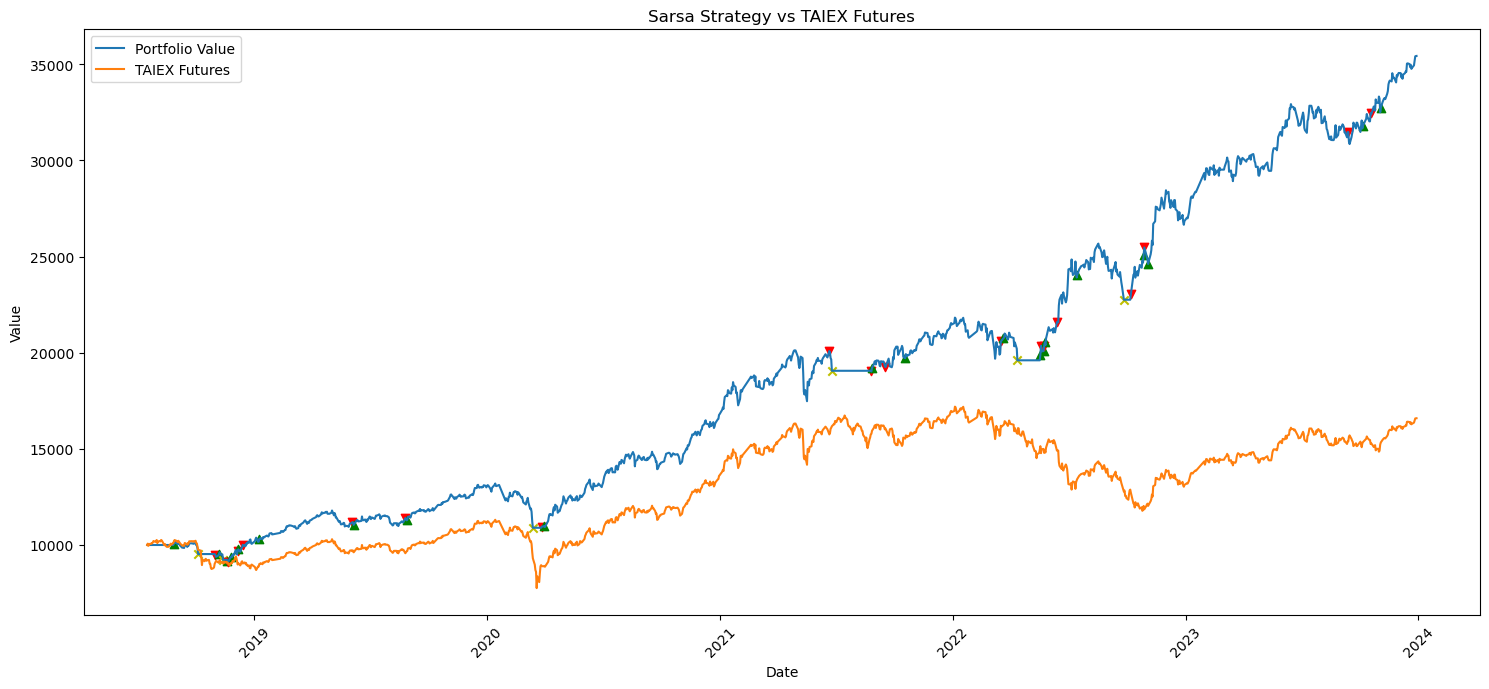


Performance Metrics:
Total Return (%): 254.3860
Annualized Return (%): 27.0214
Sharpe Ratio: 1.5730
Max Drawdown (%): 17.4453
Win Rate (%): 50.4876


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.1, alpha=0.1, gamma=0.9, epsilon_decay=0.995):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    df['Return'] = df['Close'].pct_change()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row, ma_slope_threshold, rsi_threshold):
    momentum = "Positive" if row['Momentum'] > 0 else "Negative"
    ma_trend = "Up" if row['MA20_slope'] > ma_slope_threshold else "Down"
    rsi_state = "OverBought" if row['RSI'] > rsi_threshold else "OverSold" if row['RSI'] < (100 - rsi_threshold) else "Normal"
    macd_state = "Bullish" if row['MACD'] > row['Signal'] else "Bearish"
    return f"{momentum}_{ma_trend}_{rsi_state}_{macd_state}"

def calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses):
    base_reward = return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    profit_streak_bonus = 0.002 * consecutive_profits if base_reward > 0 else 0
    loss_streak_penalty = -0.002 * consecutive_losses if base_reward < 0 else 0
    return base_reward + profit_streak_bonus + loss_streak_penalty

def run_sarsa(data, ma_slope_threshold, rsi_threshold, episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1, epsilon_decay=0.995):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"], epsilon=epsilon, alpha=alpha, gamma=gamma, epsilon_decay=epsilon_decay)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        episode_reward = 0
        consecutive_profits = 0
        consecutive_losses = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses)
            episode_reward += reward
            
            if reward > 0:
                consecutive_profits += 1
                consecutive_losses = 0
            elif reward < 0:
                consecutive_losses += 1
                consecutive_profits = 0
            
            next_state = define_state(row, ma_slope_threshold, rsi_threshold)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, ma_slope_threshold, rsi_threshold, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low']))
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High']))
        
        if action == "Buy" and position != "Long":
            position = "Long"
            entry_price = row['Close']
            trades.append(("Buy", row.name, row['Close']))
        elif action == "Sell" and position != "Short":
            position = "Short"
            entry_price = row['Close']
            trades.append(("Sell", row.name, row['Close']))
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        LSTM(32),
        Dense(2)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def prepare_data_for_lstm(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append([data[i + lookback, 0], data[i + lookback, 1]])  # MA_slope and RSI
    return np.array(X), np.array(y)

def optimize_parameters_with_lstm(data):
    features = ['MA20_slope', 'RSI']
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data[features])
    
    X, y = prepare_data_for_lstm(scaled_data)
    
    model = create_lstm_model((X.shape[1], X.shape[2]))
    model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    
    predictions = model.predict(X)
    ma_slope_threshold = np.mean(predictions[:, 0])
    rsi_threshold = np.mean(predictions[:, 1]) * 100  # Scale back to 0-100 range
    
    return ma_slope_threshold, rsi_threshold

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

# 主程序
if __name__ == "__main__":
    file_path = "TX_daily.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 将数据集分为训练集和测试集（1:1）
        split_index = len(data) // 2
        train_data = data[:split_index]
        test_data = data[split_index:]

        # 使用LSTM优化参数
        ma_slope_threshold, rsi_threshold = optimize_parameters_with_lstm(train_data)
        print(f"Optimized MA slope threshold: {ma_slope_threshold:.4f}")
        print(f"Optimized RSI threshold: {rsi_threshold:.4f}")

        # 训练模型
        trained_agent, rewards_history = run_sarsa(train_data, ma_slope_threshold, rsi_threshold, episodes=1000)
        plot_learning_curve(rewards_history)

        # 在测试集上评估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, ma_slope_threshold, rsi_threshold)
        plot_results(test_data, portfolio_values, trades)

        # 计算性能指标
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Optimized MA slope threshold: 0.5883
Optimized RSI threshold: 46.9161


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [03:46<00:00,  4.42it/s]


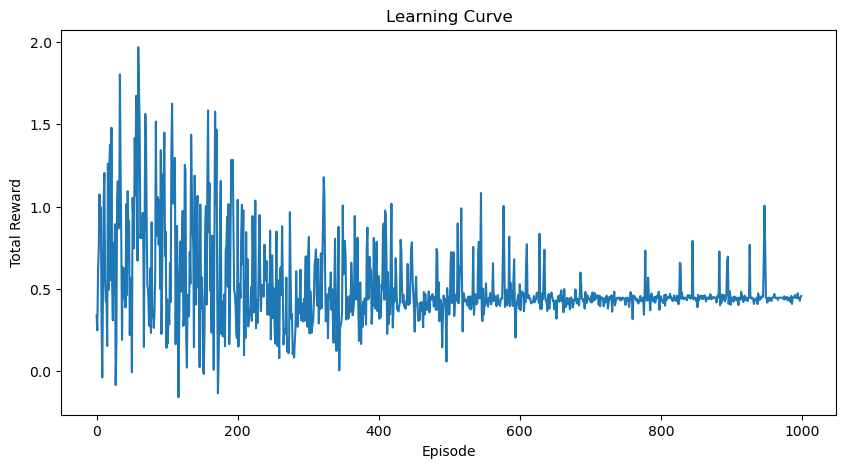

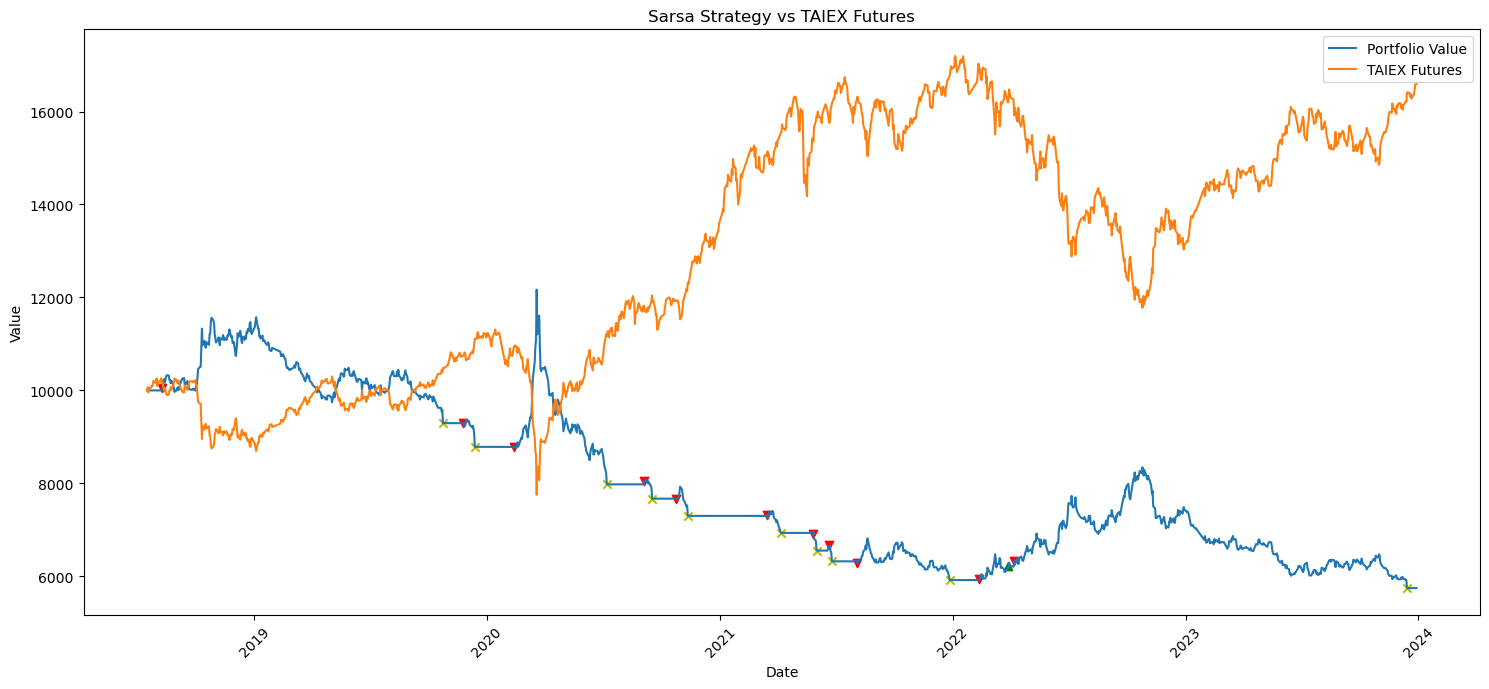


Performance Metrics:
Total Return (%): -42.5228
Annualized Return (%): -9.9397
Sharpe Ratio: -0.5494
Max Drawdown (%): 52.7624
Win Rate (%): 33.7584


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.1, alpha=0.1, gamma=0.9, epsilon_decay=0.995):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    df['Return'] = df['Close'].pct_change()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row, ma_slope_threshold, rsi_threshold):
    momentum = "Positive" if row['Momentum'] > 0 else "Negative"
    ma_trend = "Up" if row['MA20_slope'] > ma_slope_threshold else "Down"
    rsi_state = "OverBought" if row['RSI'] > rsi_threshold else "OverSold" if row['RSI'] < (100 - rsi_threshold) else "Normal"
    macd_state = "Bullish" if row['MACD'] > row['Signal'] else "Bearish"
    return f"{momentum}_{ma_trend}_{rsi_state}_{macd_state}"

def calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses):
    base_reward = return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    profit_streak_bonus = 0.003 * consecutive_profits if base_reward > 0 else 0
    loss_streak_penalty = -0.003 * consecutive_losses if base_reward < 0 else 0
    return base_reward + profit_streak_bonus + loss_streak_penalty

def run_sarsa(data, ma_slope_threshold, rsi_threshold, episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1, epsilon_decay=0.995):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"], epsilon=epsilon, alpha=alpha, gamma=gamma, epsilon_decay=epsilon_decay)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        episode_reward = 0
        consecutive_profits = 0
        consecutive_losses = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses)
            episode_reward += reward
            
            if reward > 0:
                consecutive_profits += 1
                consecutive_losses = 0
            elif reward < 0:
                consecutive_losses += 1
                consecutive_profits = 0
            
            next_state = define_state(row, ma_slope_threshold, rsi_threshold)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, ma_slope_threshold, rsi_threshold, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low']))
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High']))
        
        if action == "Buy" and position != "Long":
            position = "Long"
            entry_price = row['Close']
            trades.append(("Buy", row.name, row['Close']))
        elif action == "Sell" and position != "Short":
            position = "Short"
            entry_price = row['Close']
            trades.append(("Sell", row.name, row['Close']))
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        LSTM(32),
        Dense(2)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def prepare_data_for_lstm(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append([data[i + lookback, 0], data[i + lookback, 1]])  # MA_slope and RSI
    return np.array(X), np.array(y)

def optimize_parameters_with_lstm(data):
    features = ['MA20_slope', 'RSI']
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data[features])
    
    X, y = prepare_data_for_lstm(scaled_data)
    
    model = create_lstm_model((X.shape[1], X.shape[2]))
    model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    
    predictions = model.predict(X)
    ma_slope_threshold = np.mean(predictions[:, 0])
    rsi_threshold = np.mean(predictions[:, 1]) * 100  # Scale back to 0-100 range
    
    return ma_slope_threshold, rsi_threshold

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

# 主程序
if __name__ == "__main__":
    file_path = "TX_daily.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 将数据集分为训练集和测试集（1:1）
        split_index = len(data) // 2
        train_data = data[:split_index]
        test_data = data[split_index:]

        # 使用LSTM优化参数
        ma_slope_threshold, rsi_threshold = optimize_parameters_with_lstm(train_data)
        print(f"Optimized MA slope threshold: {ma_slope_threshold:.4f}")
        print(f"Optimized RSI threshold: {rsi_threshold:.4f}")

        # 训练模型
        trained_agent, rewards_history = run_sarsa(train_data, ma_slope_threshold, rsi_threshold, episodes=1000)
        plot_learning_curve(rewards_history)

        # 在测试集上评估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, ma_slope_threshold, rsi_threshold)
        plot_results(test_data, portfolio_values, trades)

        # 计算性能指标
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")

訓練資料筆數: 2133
測試資料筆數: 534


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Optimized MA slope threshold: 0.6366
Optimized RSI threshold: 52.7948


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [06:07<00:00,  2.72it/s]


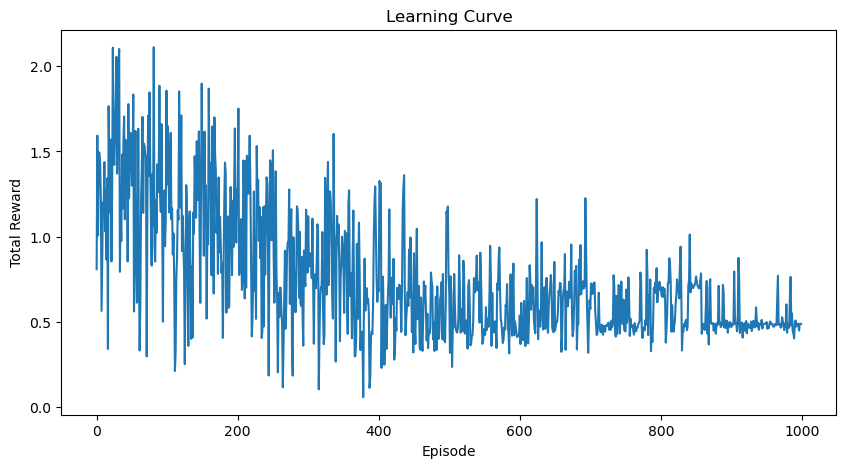

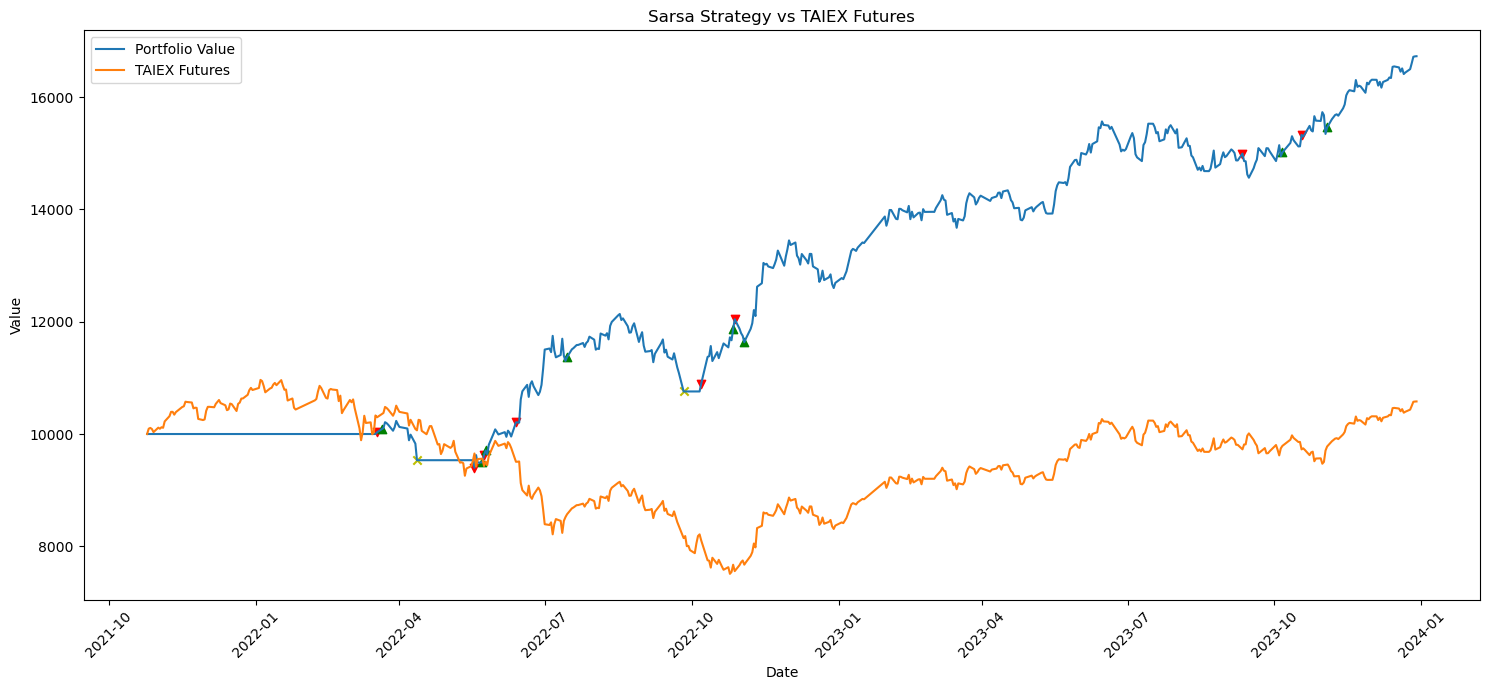


Performance Metrics:
Total Return (%): 67.2940
Annualized Return (%): 27.5441
Sharpe Ratio: 1.7256
Max Drawdown (%): 11.3679
Win Rate (%): 42.5891


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.1, alpha=0.1, gamma=0.9, epsilon_decay=0.995):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    df['Return'] = df['Close'].pct_change()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row, ma_slope_threshold, rsi_threshold):
    momentum = "Positive" if row['Momentum'] > 0 else "Negative"
    ma_trend = "Up" if row['MA20_slope'] > ma_slope_threshold else "Down"
    rsi_state = "OverBought" if row['RSI'] > rsi_threshold else "OverSold" if row['RSI'] < (100 - rsi_threshold) else "Normal"
    macd_state = "Bullish" if row['MACD'] > row['Signal'] else "Bearish"
    return f"{momentum}_{ma_trend}_{rsi_state}_{macd_state}"

def calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses):
    base_reward = return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    profit_streak_bonus = 0.002 * consecutive_profits if base_reward > 0 else 0
    loss_streak_penalty = -0.002 * consecutive_losses if base_reward < 0 else 0
    return base_reward + profit_streak_bonus + loss_streak_penalty

def run_sarsa(data, ma_slope_threshold, rsi_threshold, episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1, epsilon_decay=0.995):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"], epsilon=epsilon, alpha=alpha, gamma=gamma, epsilon_decay=epsilon_decay)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        episode_reward = 0
        consecutive_profits = 0
        consecutive_losses = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses)
            episode_reward += reward
            
            if reward > 0:
                consecutive_profits += 1
                consecutive_losses = 0
            elif reward < 0:
                consecutive_losses += 1
                consecutive_profits = 0
            
            next_state = define_state(row, ma_slope_threshold, rsi_threshold)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, ma_slope_threshold, rsi_threshold, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low']))
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High']))
        
        if action == "Buy" and position != "Long":
            position = "Long"
            entry_price = row['Close']
            trades.append(("Buy", row.name, row['Close']))
        elif action == "Sell" and position != "Short":
            position = "Short"
            entry_price = row['Close']
            trades.append(("Sell", row.name, row['Close']))
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        LSTM(32),
        Dense(2)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def prepare_data_for_lstm(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append([data[i + lookback, 0], data[i + lookback, 1]])  # MA_slope and RSI
    return np.array(X), np.array(y)

def optimize_parameters_with_lstm(data):
    features = ['MA20_slope', 'RSI']
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data[features])
    
    X, y = prepare_data_for_lstm(scaled_data)
    
    model = create_lstm_model((X.shape[1], X.shape[2]))
    model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    
    predictions = model.predict(X)
    ma_slope_threshold = np.mean(predictions[:, 0])
    rsi_threshold = np.mean(predictions[:, 1]) * 100  # Scale back to 0-100 range
    
    return ma_slope_threshold, rsi_threshold

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

# 主程序
if __name__ == "__main__":
    file_path = "TX_daily.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 将数据集分为训练集和测试集（1:1）
        split_ratio = 0.8  # 80% 用於訓練
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")

        # 使用LSTM优化参数
        ma_slope_threshold, rsi_threshold = optimize_parameters_with_lstm(train_data)
        print(f"Optimized MA slope threshold: {ma_slope_threshold:.4f}")
        print(f"Optimized RSI threshold: {rsi_threshold:.4f}")

        # 训练模型
        trained_agent, rewards_history = run_sarsa(train_data, ma_slope_threshold, rsi_threshold, episodes=1000)
        plot_learning_curve(rewards_history)

        # 在测试集上评估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, ma_slope_threshold, rsi_threshold)
        plot_results(test_data, portfolio_values, trades)

        # 计算性能指标
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")


資料集大小:
總資料筆數: 2667
訓練資料筆數: 2133
測試資料筆數: 534
--------------------------------------------------


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Optimized MA slope threshold: 0.6381
Optimized RSI threshold: 55.1326


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [06:42<00:00,  2.49it/s]


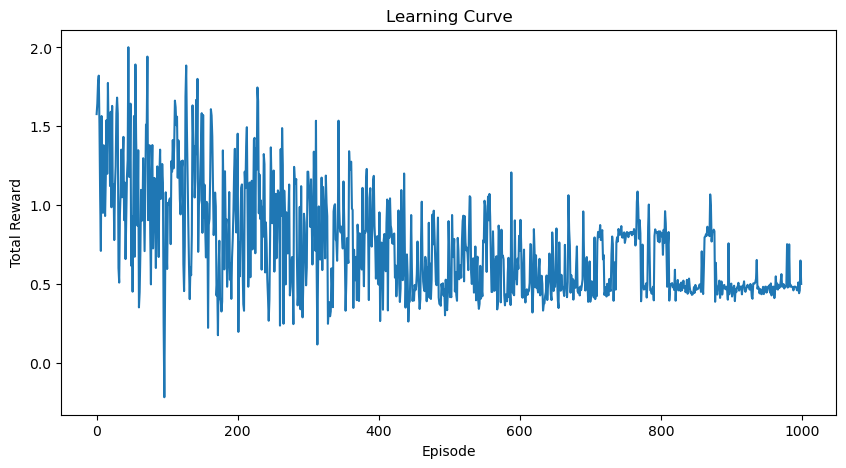


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2022-03-18 00:00:00	Buy		17391.00		Enter Long
2022-04-18 00:00:00	StopLoss		16813.00		Exit Long
2022-05-18 00:00:00	Buy		16302.00		Enter Long
2022-05-19 00:00:00	Sell		15911.00		Enter Short
2022-05-23 00:00:00	Buy		16147.00		Enter Long
2022-05-24 00:00:00	Sell		15926.00		Enter Short
2022-05-25 00:00:00	Buy		16060.00		Enter Long
2022-06-16 00:00:00	StopLoss		15382.00		Exit Long
2022-07-14 00:00:00	Sell		14389.00		Enter Short
2022-07-15 00:00:00	Buy		14475.00		Enter Long
2022-09-26 00:00:00	StopLoss		13740.00		Exit Long
2022-10-07 00:00:00	Sell		13689.00		Enter Short
2022-10-27 00:00:00	Buy		12956.00		Enter Long
2022-10-28 00:00:00	Sell		12764.00		Enter Short
2022-10-31 00:00:00	Buy		12943.00		Enter Long
2023-09-13 00:00:00	Sell		16577.00		Enter Short
2023-09-18 00:00:00	Buy		16709.00		Enter Long
2023-09-22 00:00:00	StopLoss		16188.00		Exit Long
2023-10-06 00:00:00	Buy		16531.00		Enter Long
2023

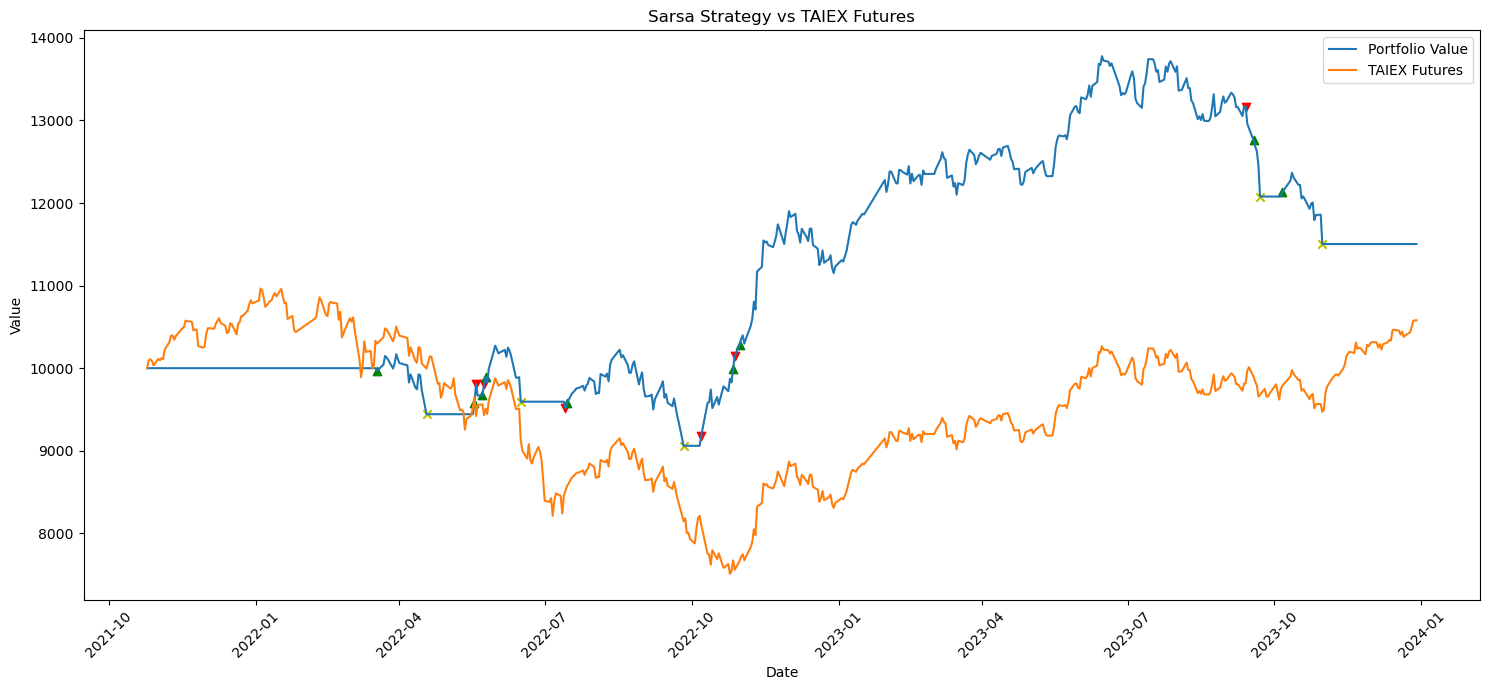


Performance Metrics:
Total Return (%): 15.0322
Annualized Return (%): 6.8452
Sharpe Ratio: 0.5510
Max Drawdown (%): 16.5091
Win Rate (%): 34.5216


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.1, alpha=0.1, gamma=0.9, epsilon_decay=0.995):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    df['Return'] = df['Close'].pct_change()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row, ma_slope_threshold, rsi_threshold):
    momentum = "Positive" if row['Momentum'] > 0 else "Negative"
    ma_trend = "Up" if row['MA20_slope'] > ma_slope_threshold else "Down"
    rsi_state = "OverBought" if row['RSI'] > rsi_threshold else "OverSold" if row['RSI'] < (100 - rsi_threshold) else "Normal"
    macd_state = "Bullish" if row['MACD'] > row['Signal'] else "Bearish"
    return f"{momentum}_{ma_trend}_{rsi_state}_{macd_state}"

def calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses):
    base_reward = return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    profit_streak_bonus = 0.002 * consecutive_profits if base_reward > 0 else 0
    loss_streak_penalty = -0.002 * consecutive_losses if base_reward < 0 else 0
    return base_reward + profit_streak_bonus + loss_streak_penalty

def run_sarsa(data, ma_slope_threshold, rsi_threshold, episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1, epsilon_decay=0.995):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"], epsilon=epsilon, alpha=alpha, gamma=gamma, epsilon_decay=epsilon_decay)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        episode_reward = 0
        consecutive_profits = 0
        consecutive_losses = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses)
            episode_reward += reward
            
            if reward > 0:
                consecutive_profits += 1
                consecutive_losses = 0
            elif reward < 0:
                consecutive_losses += 1
                consecutive_profits = 0
            
            next_state = define_state(row, ma_slope_threshold, rsi_threshold)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, ma_slope_threshold, rsi_threshold, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, ma_slope_threshold, rsi_threshold)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
        
        if action == "Buy" and position != "Long":
            position = "Long"
            entry_price = row['Close']
            trades.append(("Buy", row.name, row['Close'], "Enter Long"))
        elif action == "Sell" and position != "Short":
            position = "Short"
            entry_price = row['Close']
            trades.append(("Sell", row.name, row['Close'], "Enter Short"))
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        LSTM(32),
        Dense(2)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def prepare_data_for_lstm(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append([data[i + lookback, 0], data[i + lookback, 1]])
    return np.array(X), np.array(y)

def optimize_parameters_with_lstm(data):
    features = ['MA20_slope', 'RSI']
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data[features])
    
    X, y = prepare_data_for_lstm(scaled_data)
    
    model = create_lstm_model((X.shape[1], X.shape[2]))
    model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
    
    predictions = model.predict(X)
    ma_slope_threshold = np.mean(predictions[:, 0])
    rsi_threshold = np.mean(predictions[:, 1]) * 100
    
    return ma_slope_threshold, rsi_threshold

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def print_trade_details(trades):
    print("\n交易明細:")
    print("時間\t\t\t類型\t\t價格\t\t說明")
    print("-" * 70)
    for trade in trades:
        print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

# 主程序
if __name__ == "__main__":
    file_path = "TX_daily.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 修改為8:2的分割比例
        split_ratio = 0.8  # 80% 用於訓練
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        # 在分割資料後立即輸出資料筆數
        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 使用LSTM優化參數
        ma_slope_threshold, rsi_threshold = optimize_parameters_with_lstm(train_data)
        print(f"Optimized MA slope threshold: {ma_slope_threshold:.4f}")
        print(f"Optimized RSI threshold: {rsi_threshold:.4f}")

        # 訓練模型
        trained_agent, rewards_history = run_sarsa(train_data, ma_slope_threshold, rsi_threshold, episodes=1000)
        plot_learning_curve(rewards_history)

        # 在測試集上評估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, ma_slope_threshold, rsi_threshold)
        
        # 輸出交易明細
        print_trade_details(trades)
        
        plot_results(test_data, portfolio_values, trades)

        # 計算性能指標
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def check_data_quality(df):
    """檢查資料品質"""
    print("1. 基本資料資訊：")
    print("-" * 50)
    print(f"資料筆數: {len(df)}")
    print(f"資料時間範圍: {df.index.min()} 到 {df.index.max()}")
    print(f"交易天數: {len(df.index.unique())} 天")
    print("\n2. 缺失值檢查：")
    print("-" * 50)
    print(df.isnull().sum())
    
    print("\n3. 基本統計資訊：")
    print("-" * 50)
    print(df.describe())
    
    print("\n4. 基差統計：")
    print("-" * 50)
    basis_stats = {
        "平均基差": df['Basis'].mean(),
        "基差標準差": df['Basis'].std(),
        "最大基差": df['Basis'].max(),
        "最小基差": df['Basis'].min(),
        "正基差天數": (df['Basis'] > 0).sum(),
        "負基差天數": (df['Basis'] < 0).sum()
    }
    for key, value in basis_stats.items():
        print(f"{key}: {value:.2f}")

def plot_data_analysis(df):
    """繪製資料分析圖表"""
    # 設定圖表風格
    plt.style.use('seaborn')
    
    # 創建子圖
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. 價格走勢圖
    axes[0, 0].plot(df.index, df['Close'], label='收盤價')
    axes[0, 0].set_title('價格走勢')
    axes[0, 0].set_xlabel('日期')
    axes[0, 0].set_ylabel('價格')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. 基差走勢圖
    axes[0, 1].plot(df.index, df['Basis'], label='基差', color='orange')
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_title('基差走勢')
    axes[0, 1].set_xlabel('日期')
    axes[0, 1].set_ylabel('基差')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. 基差分布圖
    sns.histplot(df['Basis'], bins=20, ax=axes[1, 0])
    axes[1, 0].set_title('基差分布')
    axes[1, 0].set_xlabel('基差')
    
    # 4. 成交量圖
    axes[1, 1].bar(df.index, df['Volume'])
    axes[1, 1].set_title('成交量')
    axes[1, 1].set_xlabel('日期')
    axes[1, 1].set_ylabel('成交量')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

def check_data_abnormalities(df):
    """檢查異常值"""
    print("5. 異常值檢查：")
    print("-" * 50)
    
    # 使用Z-score方法檢查異常值
    z_scores = {}
    for column in ['Open', 'High', 'Low', 'Close', 'Basis', 'Volume']:
        z_score = np.abs((df[column] - df[column].mean()) / df[column].std())
        abnormal = z_score > 3
        z_scores[column] = df[abnormal]
    
    for column, abnormal_data in z_scores.items():
        if len(abnormal_data) > 0:
            print(f"\n{column} 可能的異常值：")
            print(abnormal_data)

def main():
    # 讀取數據
    try:
        df = pd.read_csv('TX_daily_1220.csv')
        # 轉換日期格式
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        
        # 執行檢查
        check_data_quality(df)
        plot_data_analysis(df)
        check_data_abnormalities(df)
        
    except Exception as e:
        print(f"讀取資料時發生錯誤: {e}")

if __name__ == "__main__":
    main()

1. 基本資料資訊：
--------------------------------------------------
資料筆數: 4173
資料時間範圍: 2008-01-02 00:00:00 到 2024-12-19 00:00:00
交易天數: 4173 天

2. 缺失值檢查：
--------------------------------------------------
Open      0
High      0
Low       0
Close     0
Basis     0
Volume    0
dtype: int64

3. 基本統計資訊：
--------------------------------------------------
             Basis
count  4173.000000
mean     24.222298
std      47.593900
min    -220.110000
25%      -1.540000
50%      14.570000
75%      40.030000
max     456.880000

4. 基差統計：
--------------------------------------------------
平均基差: 24.22
基差標準差: 47.59
最大基差: 456.88
最小基差: -220.11
正基差天數: 3051.00
負基差天數: 1121.00
讀取資料時發生錯誤: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)



資料集大小:
總資料筆數: 4149
訓練資料筆數: 2904
測試資料筆數: 1245
--------------------------------------------------


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [06:25<00:00,  2.59it/s]


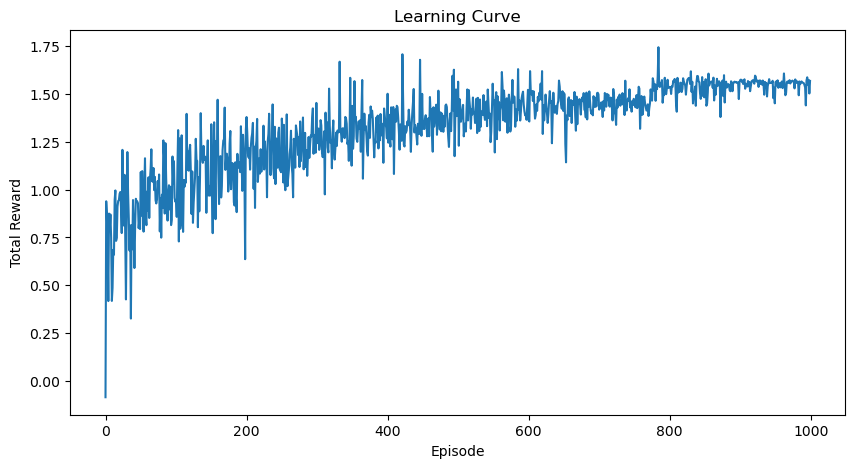


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2012-11-13 00:00:00	Sell		7096.00		Enter Short
2012-10-25 00:00:00	StopLoss		7319.00		Exit Short
2012-09-11 00:00:00	Sell		7466.00		Enter Short
2012-04-18 00:00:00	StopLoss		7692.00		Exit Short
2012-02-03 00:00:00	Sell		7642.00		Enter Short
2011-12-07 00:00:00	Buy		7054.00		Enter Long
2011-11-30 00:00:00	StopLoss		6826.00		Exit Long
2011-10-04 00:00:00	Buy		7094.00		Enter Long
2011-09-26 00:00:00	StopLoss		6855.00		Exit Long
2011-09-05 00:00:00	Sell		7480.00		Enter Short
2011-09-02 00:00:00	StopLoss		7745.00		Exit Short
2011-08-19 00:00:00	Sell		7195.00		Enter Short
2011-08-18 00:00:00	StopLoss		7584.00		Exit Short
2011-07-08 00:00:00	Buy		8638.00		Enter Long
2011-07-05 00:00:00	Sell		8628.00		Enter Short
2011-06-15 00:00:00	Buy		8839.00		Enter Long
2011-05-05 00:00:00	Sell		9050.00		Enter Short
2010-12-09 00:00:00	Buy		8789.00		Enter Long
2010-12-01 00:00:00	StopLoss		8411.00		Exit Long
2010-

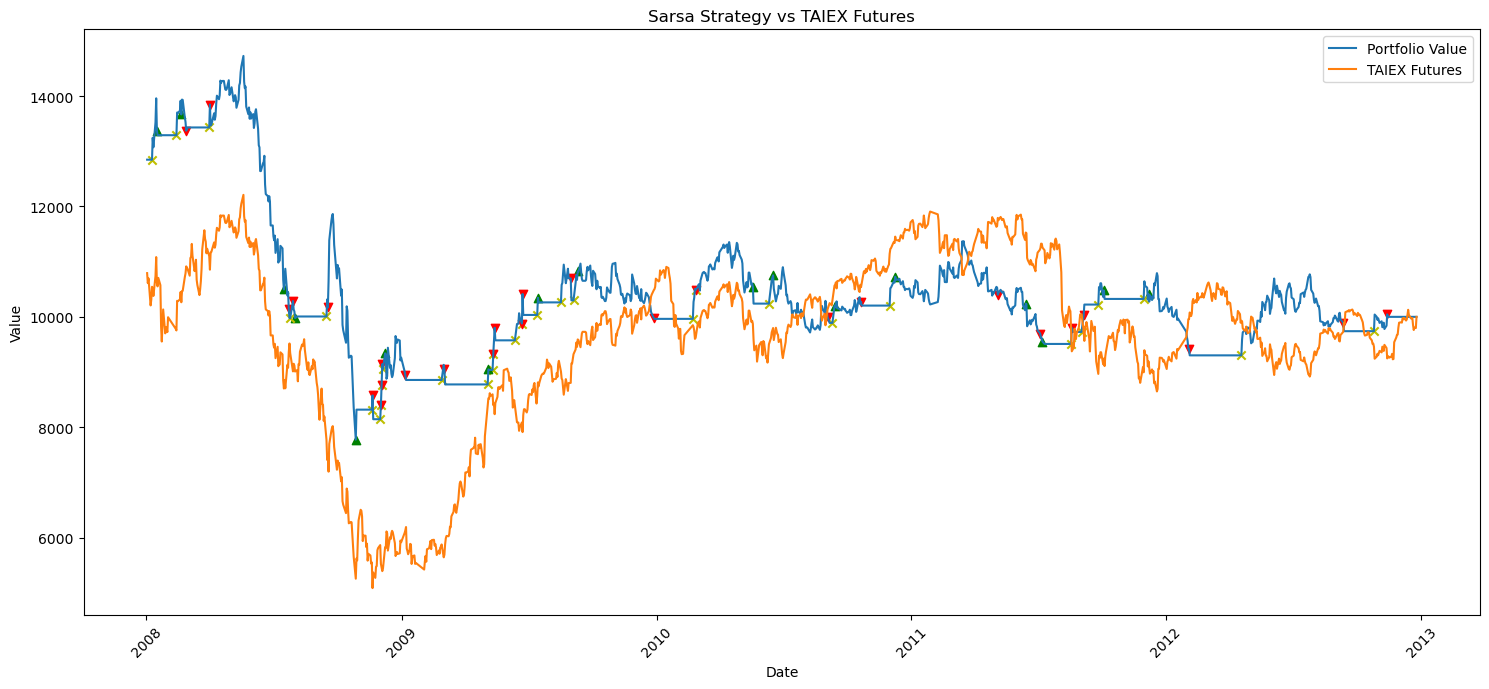


Performance Metrics:
Total Return (%): 28.4743
Annualized Return (%): 5.2066
Sharpe Ratio: 0.3579
Max Drawdown (%): 31.6189
Win Rate (%): 31.0289


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.1, alpha=0.1, gamma=0.9, epsilon_decay=0.995):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 基本計算
    df['Return'] = df['Close'].pct_change()
    
    # 基差相關指標
    df['Basis_MA20'] = df['Basis'].rolling(window=20).mean()
    df['Basis_STD'] = df['Basis'].rolling(window=20).std()
    df['Basis_Z_Score'] = (df['Basis'] - df['Basis_MA20']) / df['Basis_STD']
    
    # 技術指標
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

# 可以修改 define_state 函數，加入更細緻的狀態判斷
def define_state(row, thresholds):
    # 增加趨勢強度判斷
    ma_trend_strength = abs(row['MA20_slope'])
    trend_state = (
        "Strong_Up" if row['MA20_slope'] > thresholds['ma'] * 2 else
        "Weak_Up" if row['MA20_slope'] > thresholds['ma'] else
        "Strong_Down" if row['MA20_slope'] < -thresholds['ma'] * 2 else
        "Weak_Down"
    )
    
    # 增加 KD 指標交叉判斷
    kd_state = (
        "Golden_Cross" if row['K'] > row['D'] and row['K'].shift(1) <= row['D'].shift(1) else
        "Death_Cross" if row['K'] < row['D'] and row['K'].shift(1) >= row['D'].shift(1) else
        "Normal"
    )

# 修改 calculate_reward 函數，增加風險控制獎勵
def calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses, basis_z_score):
    base_reward = return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    
    # 加入波動率懲罰
    volatility_penalty = -0.001 * data['Close'].rolling(20).std().iloc[-1]
    
    # 加入超買超賣的風險控制
    risk_penalty = 0
    if position == "Long" and row['RSI'] > 80:
        risk_penalty = -0.001
    elif position == "Short" and row['RSI'] < 20:
        risk_penalty = -0.001

def run_sarsa(data, thresholds, episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1, epsilon_decay=0.995):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"], epsilon=epsilon, alpha=alpha, gamma=gamma, epsilon_decay=epsilon_decay)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], thresholds)
        action = agent.get_action(state)
        episode_reward = 0
        consecutive_profits = 0
        consecutive_losses = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            basis_z_score = row['Basis_Z_Score']
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, 
                                   consecutive_profits, consecutive_losses,
                                   basis_z_score)
            episode_reward += reward
            
            if reward > 0:
                consecutive_profits += 1
                consecutive_losses = 0
            elif reward < 0:
                consecutive_losses += 1
                consecutive_profits = 0
            
            next_state = define_state(row, thresholds)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, thresholds, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, thresholds)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
        
        if action == "Buy" and position != "Long":
            position = "Long"
            entry_price = row['Close']
            trades.append(("Buy", row.name, row['Close'], "Enter Long"))
        elif action == "Sell" and position != "Short":
            position = "Short"
            entry_price = row['Close']
            trades.append(("Sell", row.name, row['Close'], "Enter Short"))
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def print_trade_details(trades):
    print("\n交易明細:")
    print("時間\t\t\t類型\t\t價格\t\t說明")
    print("-" * 70)
    for trade in trades:
        print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 設定閾值
        thresholds = {
            'ma': 0.001,  # MA趨勢判斷閾值
            'rsi': 70     # RSI超買超賣閾值
        }
        
        # 修改為7:3的分割比例
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 訓練模型
        trained_agent, rewards_history = run_sarsa(train_data, thresholds, episodes=1000)
        plot_learning_curve(rewards_history)

        # 在測試集上評估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, thresholds)
        
        # 輸出交易明細
        print_trade_details(trades)
        
        plot_results(test_data, portfolio_values, trades)

        # 計算性能指標
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")


資料集大小:
總資料筆數: 4149
訓練資料筆數: 3319
測試資料筆數: 830
--------------------------------------------------


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [04:59<00:00,  3.34it/s]


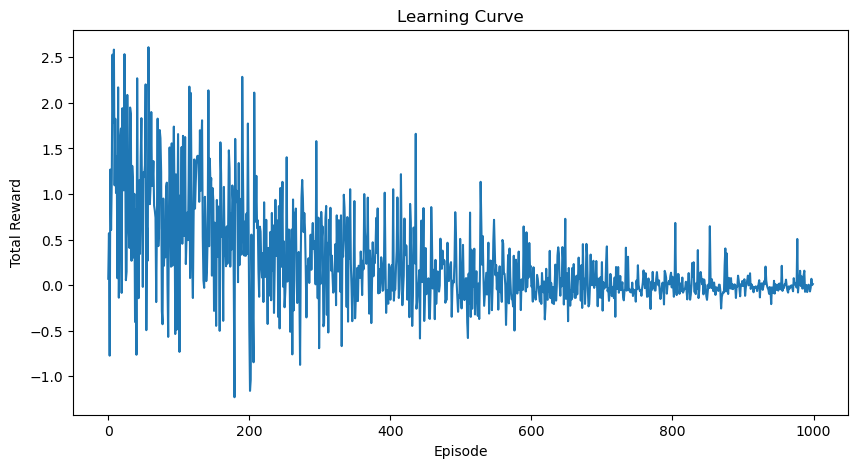


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2021-11-04 00:00:00	Buy		17075.00		Enter Long
2021-11-18 00:00:00	TimeExit		17860.00		Exit Long
2023-07-20 00:00:00	Buy		17126.00		Enter Long
2023-08-04 00:00:00	TimeExit		16824.00		Exit Long


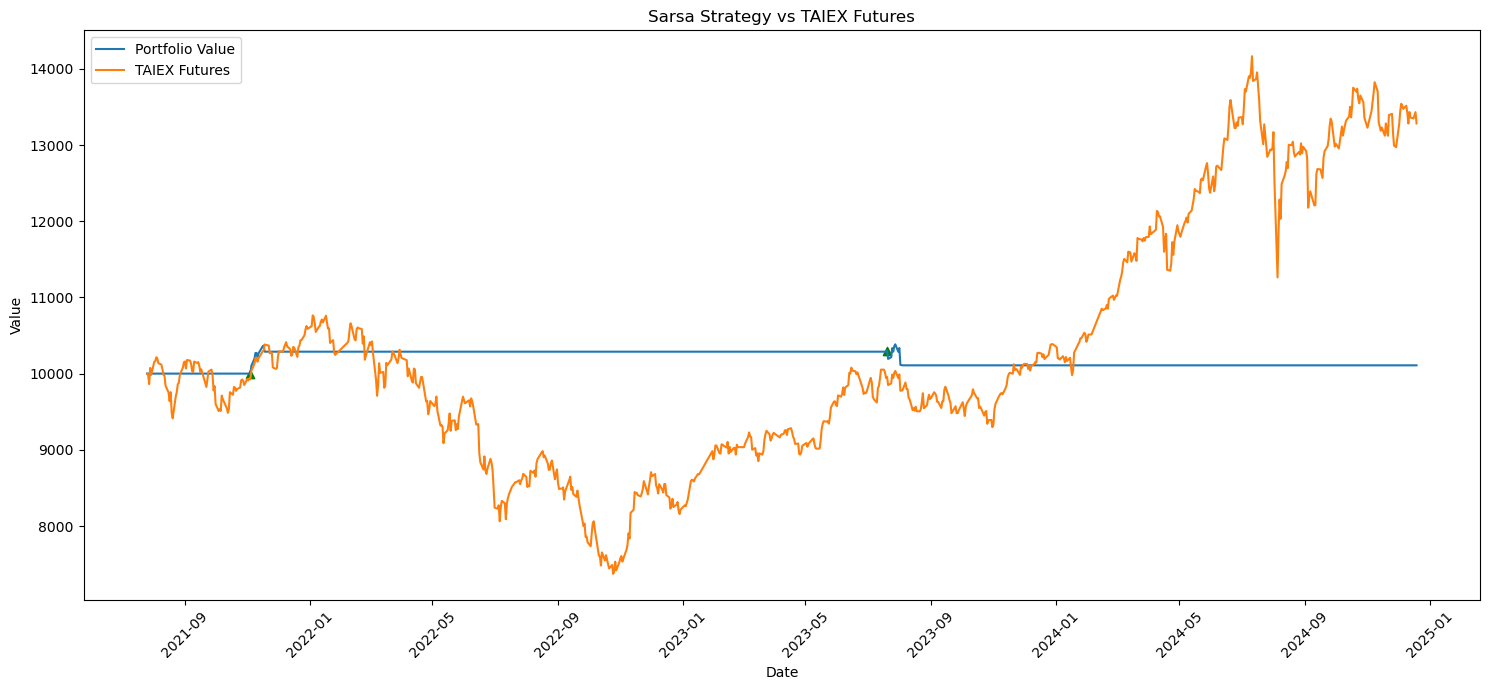


Performance Metrics:
Total Return (%): 1.0859
Annualized Return (%): 0.3289
Sharpe Ratio: 0.1737
Max Drawdown (%): 2.6532
Win Rate (%): 1.5682


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.2, alpha=0.2, gamma=0.8, epsilon_decay=0.995):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 基本計算
    df['Return'] = df['Close'].pct_change()
    
    # 移動平均
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    
    # 基差相關
    df['Basis_MA20'] = df['Basis'].rolling(window=20).mean()
    df['Basis_STD'] = df['Basis'].rolling(window=20).std()
    df['Basis_Z_Score'] = (df['Basis'] - df['Basis_MA20']) / df['Basis_STD']
    
    # 技術指標
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    # 移除NaN值
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row, thresholds):
    # 簡化的趨勢狀態
    trend_state = "Up" if row['MA20_slope'] > thresholds['ma'] else "Down"
    
    # 價格相對均線位置
    price_state = "Above_MA20" if row['Close'] > row['MA20'] else "Below_MA20"
    
    # RSI狀態
    rsi_state = (
        "OverBought" if row['RSI'] > thresholds['rsi'] else
        "OverSold" if row['RSI'] < (100 - thresholds['rsi']) else
        "Normal"
    )
    
    # 基差狀態
    basis_state = (
        "Wide" if abs(row['Basis_Z_Score']) > 1.5 else
        "Normal"
    )
    
    return f"{trend_state}_{price_state}_{rsi_state}_{basis_state}"

def calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses):
    # 增加基本報酬的權重
    base_reward = 2.0 * return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    
    # 降低連續交易的影響
    profit_streak_bonus = 0.001 * consecutive_profits if base_reward > 0 else 0
    loss_streak_penalty = -0.001 * consecutive_losses if base_reward < 0 else 0
    
    return base_reward + profit_streak_bonus + loss_streak_penalty

def run_sarsa(data, thresholds, episodes=1000):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"])
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], thresholds)
        action = agent.get_action(state)
        episode_reward = 0
        consecutive_profits = 0
        consecutive_losses = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, 
                                   consecutive_profits, consecutive_losses)
            episode_reward += reward
            
            if reward > 0:
                consecutive_profits += 1
                consecutive_losses = 0
            elif reward < 0:
                consecutive_losses += 1
                consecutive_profits = 0
            
            next_state = define_state(row, thresholds)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, thresholds, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    max_holding_days = 10  # 最大持倉天數
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, thresholds)
        action = agent.get_action(state)
        return_value = row['Return']
        
        # 更新持倉天數
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days:
            if position != "Cash":
                trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
                position = "Cash"
                portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
                holding_days = 0
        
        # 執行交易
        if action == "Buy" and position != "Long":
            if row['Close'] > row['MA20'] and abs(row['Basis_Z_Score']) < 1.5:
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == "Sell" and position != "Short":
            if row['Close'] < row['MA20'] and abs(row['Basis_Z_Score']) < 1.5:
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

# [之前的其他函數保持不變: plot_learning_curve, plot_results, calculate_performance_metrics]

if __name__ == "__main__":
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 設定閾值
        thresholds = {
            'ma': 0.001,  # MA趨勢判斷閾值
            'rsi': 70,    # RSI超買超賣閾值
        }
        
        # 8:2分割
        split_ratio = 0.8
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 訓練模型
        trained_agent, rewards_history = run_sarsa(train_data, thresholds)
        plot_learning_curve(rewards_history)

        # 在測試集上評估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, thresholds)
        
        # 輸出交易明細
        print_trade_details(trades)
        
        plot_results(test_data, portfolio_values, trades)

        # 計算性能指標
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")



資料集大小:
總資料筆數: 4149
訓練資料筆數: 3319
測試資料筆數: 830
--------------------------------------------------


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [04:50<00:00,  3.45it/s]


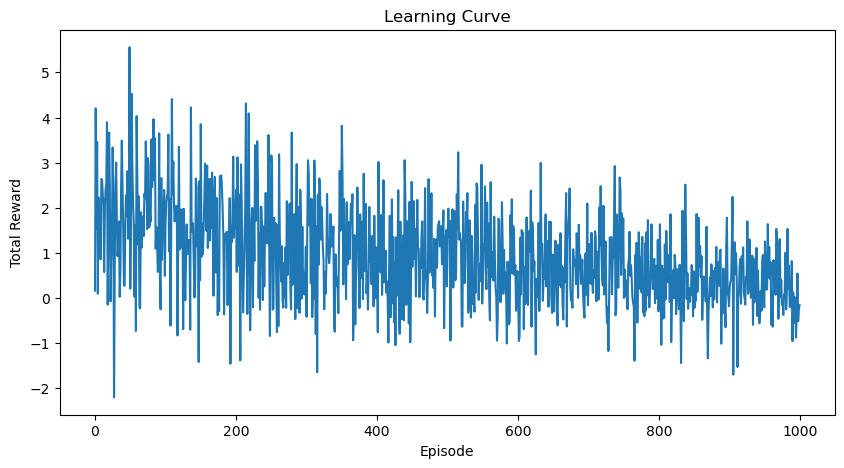


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2021-08-03 00:00:00	Buy		17484.00		Enter Long
2021-08-13 00:00:00	StopLoss		16934.00		Exit Long
2021-08-16 00:00:00	Sell		16772.00		Enter Short
2021-08-30 00:00:00	StopLoss		17353.00		Exit Short
2021-11-18 00:00:00	Buy		17860.00		Enter Long
2021-11-26 00:00:00	StopLoss		17307.00		Exit Long
2021-12-17 00:00:00	Buy		17786.00		Enter Long
2022-01-03 00:00:00	TimeExit		18273.00		Exit Long
2022-01-12 00:00:00	Buy		18375.00		Enter Long
2022-01-24 00:00:00	StopLoss		17703.00		Exit Long
2022-03-15 00:00:00	Sell		16882.00		Enter Short
2022-03-17 00:00:00	StopLoss		17470.00		Exit Short
2022-04-15 00:00:00	Sell		16983.00		Enter Short
2022-04-29 00:00:00	TimeExit		16583.00		Exit Short
2022-07-29 00:00:00	Buy		14938.00		Enter Long
2022-08-04 00:00:00	StopLoss		14461.00		Exit Long
2022-08-26 00:00:00	Buy		15241.00		Enter Long
2022-08-29 00:00:00	StopLoss		14762.00		Exit Long
2022-11-08 00:00:00	Buy		13334.00

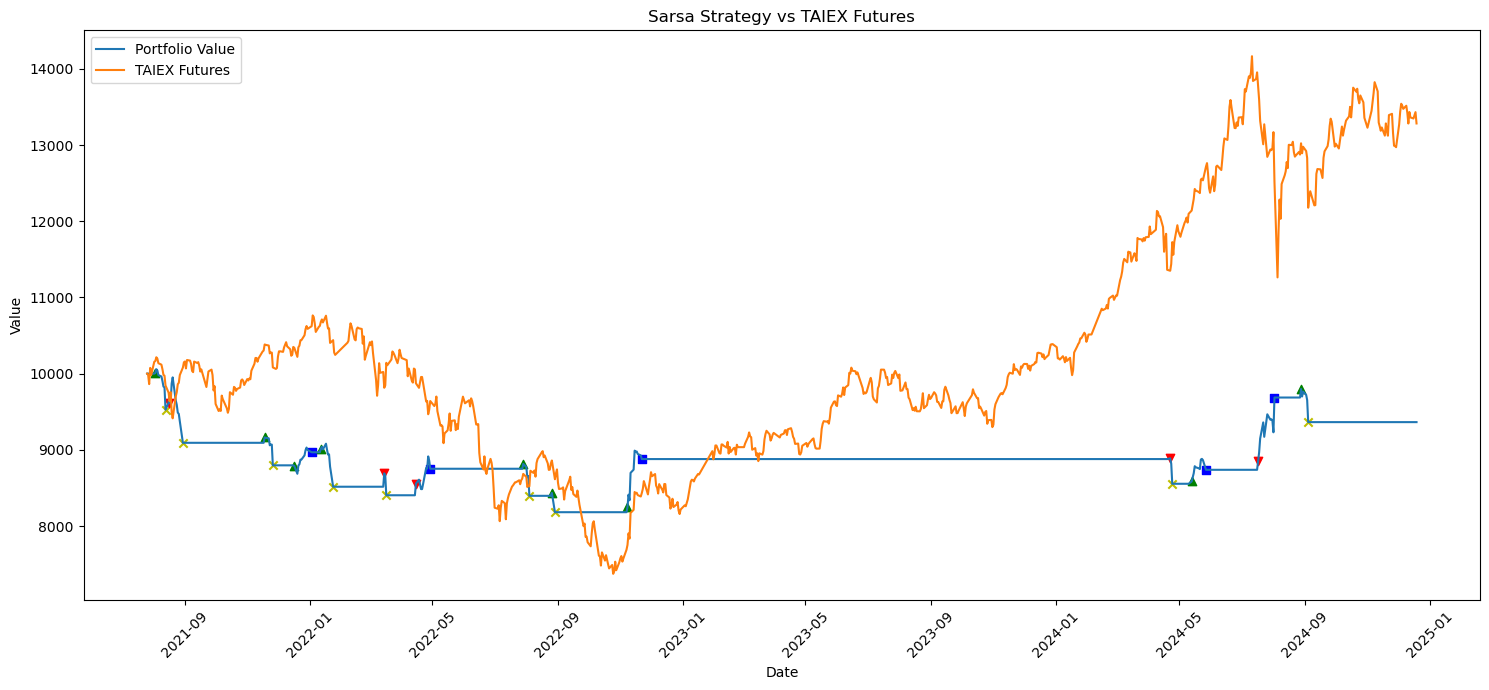


Performance Metrics:
Total Return (%): -6.3667
Annualized Return (%): -1.9799
Sharpe Ratio: -0.1910
Max Drawdown (%): 18.6569
Win Rate (%): 6.0314


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.3, alpha=0.2, gamma=0.7, epsilon_decay=0.998):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 基本計算
    df['Return'] = df['Close'].pct_change()
    
    # 移動平均
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    
    # 基差分析
    df['Basis_MA20'] = df['Basis'].rolling(window=20).mean()
    df['Basis_STD'] = df['Basis'].rolling(window=20).std()
    df['Basis_Z_Score'] = (df['Basis'] - df['Basis_MA20']) / df['Basis_STD']
    
    # 技術指標
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row, thresholds):
    # 簡化的狀態定義
    trend_state = "Up" if row['MA20_slope'] > thresholds['ma'] else "Down"
    
    rsi_state = (
        "OverBought" if row['RSI'] > thresholds['rsi'] else
        "OverSold" if row['RSI'] < (100 - thresholds['rsi']) else
        "Normal"
    )
    
    # 簡化的基差狀態
    basis_state = (
        "High" if row['Basis_Z_Score'] > 1 else
        "Low" if row['Basis_Z_Score'] < -1 else
        "Normal"
    )
    
    return f"{trend_state}_{rsi_state}_{basis_state}"

def calculate_reward(action, return_value, position, consecutive_profits, consecutive_losses):
    # 增加基本報酬的權重
    base_reward = 3.0 * return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0
    
    # 降低連續交易的影響
    profit_streak_bonus = 0.0005 * consecutive_profits if base_reward > 0 else 0
    loss_streak_penalty = -0.0005 * consecutive_losses if base_reward < 0 else 0
    
    return base_reward + profit_streak_bonus + loss_streak_penalty

def run_sarsa(data, thresholds, episodes=1000):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"])
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], thresholds)
        action = agent.get_action(state)
        episode_reward = 0
        consecutive_profits = 0
        consecutive_losses = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            return_value = row['Return']
            
            if action == "Buy" and position != "Long":
                position = "Long"
            elif action == "Sell" and position != "Short":
                position = "Short"
            
            reward = calculate_reward(action, return_value, position, 
                                   consecutive_profits, consecutive_losses)
            episode_reward += reward
            
            if reward > 0:
                consecutive_profits += 1
                consecutive_losses = 0
            elif reward < 0:
                consecutive_losses += 1
                consecutive_profits = 0
            
            next_state = define_state(row, thresholds)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, thresholds, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    max_holding_days = 10
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, thresholds)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days:
            if position != "Cash":
                trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
                position = "Cash"
                portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
                holding_days = 0
        
        # 簡化的交易條件
        if action == "Buy" and position != "Long":
            if row['Close'] > row['MA5']:  # 只需要價格在5日線上方
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == "Sell" and position != "Short":
            if row['Close'] < row['MA5']:  # 只需要價格在5日線下方
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def print_trade_details(trades):
    print("\n交易明細:")
    print("時間\t\t\t類型\t\t價格\t\t說明")
    print("-" * 70)
    for trade in trades:
        print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 簡化的閾值設定
        thresholds = {
            'ma': 0.001,  # MA趨勢判斷閾值
            'rsi': 70,    # RSI超買超賣閾值
        }
        
        # 8:2分割
        split_ratio = 0.8
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 訓練模型
        trained_agent, rewards_history = run_sarsa(train_data, thresholds)
        plot_learning_curve(rewards_history)

        # 在測試集上評估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, thresholds)
        
        # 輸出交易明細
        print_trade_details(trades)
        
        plot_results(test_data, portfolio_values, trades)

        # 計算性能指標
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.4, alpha=0.3, gamma=0.6, epsilon_decay=0.999):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 基本計算
    df['Return'] = df['Close'].pct_change()
    
    # 移動平均
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA_Trend'] = np.where(df['MA5'] > df['MA20'], 1, -1)
    
    # 趨勢強度
    df['Price_Speed'] = df['Close'].diff(5) / 5
    df['MA20_Speed'] = df['MA20'].diff(5) / 5
    
    # 基差分析
    df['Basis_MA20'] = df['Basis'].rolling(window=20).mean()
    df['Basis_STD'] = df['Basis'].rolling(window=20).std()
    df['Basis_Z_Score'] = (df['Basis'] - df['Basis_MA20']) / df['Basis_STD']
    
    # 技術指標
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    df = df.dropna()
    return df

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def define_state(row, thresholds):
    # 價格趨勢
    price_trend = (
        "Strong_Up" if row['Close'] > row['MA5'] > row['MA20'] else
        "Weak_Up" if row['Close'] > row['MA5'] else
        "Strong_Down" if row['Close'] < row['MA5'] < row['MA20'] else
        "Weak_Down"
    )
    
    # RSI狀態
    rsi_state = (
        "OverBought" if row['RSI'] > 70 else
        "OverSold" if row['RSI'] < 30 else
        "High" if row['RSI'] > 60 else
        "Low" if row['RSI'] < 40 else
        "Normal"
    )
    
    # 動量狀態
    momentum = "Positive" if row['Price_Speed'] > row['MA20_Speed'] else "Negative"
    
    return f"{price_trend}_{rsi_state}_{momentum}"

def calculate_reward(action, row, position, holding_days):
    # 基本報酬
    return_value = row['Return']
    base_reward = 5.0 * return_value if (action == "Buy" and position == "Long") or (action == "Sell" and position == "Short") else 0

     # 加入複利獎勵
    compound_reward = 0.001 * (holding_days * base_reward) if base_reward > 0 else 0
    
    # 趨勢獎勵
    trend_reward = 0.001 if (action == "Buy" and row['MA5'] > row['MA20']) or \
                          (action == "Sell" and row['MA5'] < row['MA20']) else 0
    
    # 價格動量獎勵
    momentum_reward = 0.001 if (action == "Buy" and row['Price_Speed'] > 0) or \
                              (action == "Sell" and row['Price_Speed'] < 0) else 0
    
    return base_reward + holding_reward + trend_reward + momentum_reward

def run_sarsa(data, thresholds, episodes=1000):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"])
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], thresholds)
        action = agent.get_action(state)
        episode_reward = 0
        holding_days = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            if action == "Buy" and position != "Long":
                position = "Long"
                holding_days = 0
            elif action == "Sell" and position != "Short":
                position = "Short"
                holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            episode_reward += reward
            
            next_state = define_state(row, thresholds)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, thresholds, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    max_holding_days = 20  # 增加最大持有時間
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, thresholds)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days:
            if position != "Cash":
                trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
                position = "Cash"
                portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
                holding_days = 0
        
        # 交易條件
        if action == "Buy" and position != "Long":
            if (row['Close'] > row['MA5'] and row['MA5'] > row['MA20']) or \
               (row['RSI'] < 40):  # 加入超賣條件
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == "Sell" and position != "Short":
            if (row['Close'] < row['MA5'] and row['MA5'] < row['MA20']) or \
               (row['RSI'] > 60):  # 加入超買條件
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades


if __name__ == "__main__":
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 設定閾值
        thresholds = {
            'ma': 0.001,  # MA趨勢判斷閾值
            'rsi': 70,    # RSI超買超賣閾值
        }
        
        # 8:2分割
        split_ratio = 0.8
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 訓練模型
        trained_agent, rewards_history = run_sarsa(train_data, thresholds)
        plot_learning_curve(rewards_history)

        # 在測試集上評估模型
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data, thresholds)
        
        # 輸出交易明細
        print_trade_details(trades)
        
        plot_results(test_data, portfolio_values, trades)

        # 計算性能指標
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)

        print("\nPerformance Metrics:")
        for key, value in performance_metrics.items():
            print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")




資料集大小:
總資料筆數: 4149
訓練資料筆數: 3319
測試資料筆數: 830
--------------------------------------------------


Training Progress:   0%|                                                                      | 0/1000 [00:00<?, ?it/s]


NameError: name 'holding_reward' is not defined

In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, epsilon=0.4, alpha=0.3, gamma=0.6, epsilon_decay=0.999):
        self.actions = actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: defaultdict(float))

    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def calculate_atr(df, period=14):
    tr = pd.DataFrame()
    tr['h-l'] = df['High'] - df['Low']
    tr['h-pc'] = abs(df['High'] - df['Close'].shift(1))
    tr['l-pc'] = abs(df['Low'] - df['Close'].shift(1))
    tr['tr'] = tr[['h-l', 'h-pc', 'l-pc']].max(axis=1)
    atr = tr['tr'].rolling(period).mean()
    return atr

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 基本計算
    df['Return'] = df['Close'].pct_change()
    
    # 移動平均
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA_Trend'] = np.where(df['MA5'] > df['MA20'], 1, -1)
    
    # 波動率指標
    df['ATR'] = calculate_atr(df)
    df['Volatility'] = df['Close'].rolling(window=20).std()
    
    # 動量指標
    df['ROC'] = (df['Close'] - df['Close'].shift(10)) / df['Close'].shift(10) * 100
    df['Price_Speed'] = df['Close'].diff(5) / 5
    
    # 基差分析
    df['Basis_MA20'] = df['Basis'].rolling(window=20).mean()
    df['Basis_STD'] = df['Basis'].rolling(window=20).std()
    df['Basis_Z_Score'] = (df['Basis'] - df['Basis_MA20']) / df['Basis_STD']
    df['Basis_Change'] = df['Basis'].diff()
    df['Basis_Momentum'] = df['Basis'] - df['Basis'].shift(5)
    
    # RSI和MACD
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    # 計算各指標的平均值，用於狀態判斷
    df['Volatility_MA'] = df['Volatility'].rolling(window=20).mean()
    
    df = df.dropna()
    return df

def define_state(row, thresholds):
    # 趨勢方向（結合MA和基差）
    if row['Close'] > row['MA20'] and row['Basis_Z_Score'] < 0:
        trend_state = "Strong_Up"
    elif row['Close'] > row['MA20']:
        trend_state = "Weak_Up"
    elif row['Close'] < row['MA20'] and row['Basis_Z_Score'] > 0:
        trend_state = "Strong_Down"
    else:
        trend_state = "Weak_Down"
    
    # RSI狀態
    if row['RSI'] > 70:
        rsi_state = "OverBought"
    elif row['RSI'] < 30:
        rsi_state = "OverSold"
    else:
        rsi_state = "Normal"
    
    # 基差狀態
    if abs(row['Basis_Z_Score']) > 2:
        basis_state = "Extreme"
    elif abs(row['Basis_Z_Score']) > 1.5:
        basis_state = "Wide"
    else:
        basis_state = "Normal"
    
    return f"{trend_state}_{rsi_state}_{basis_state}"



資料集大小:
總資料筆數: 4135
訓練資料筆數: 2894
測試資料筆數: 1241
--------------------------------------------------

訓練 profit 模型:


Training Progress: 100%|█████████████████████████████████████████████████████████| 1000/1000 [3:42:49<00:00, 13.37s/it]


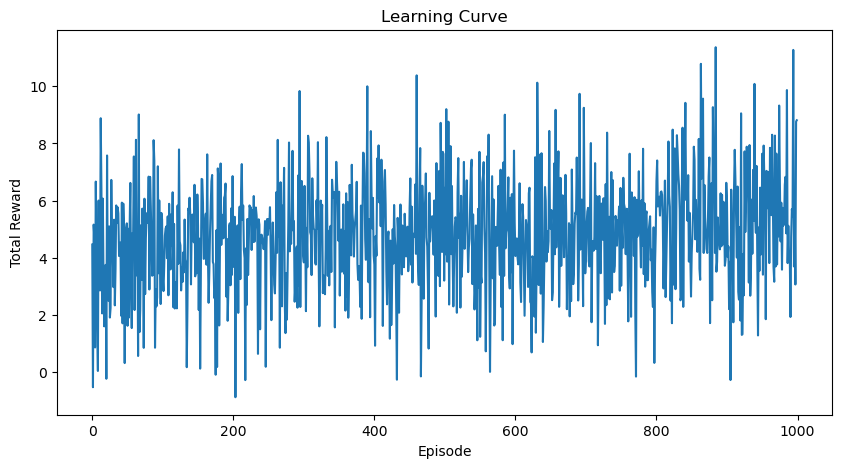


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-18 00:00:00	Buy		11593.00		Enter Long
2019-11-21 00:00:00	Sell		11544.00		Enter Short
2019-11-27 00:00:00	Buy		11647.00		Enter Long
2019-12-19 00:00:00	Sell		12030.00		Enter Short
2020-01-09 00:00:00	Buy		11968.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-04 00:00:00	Sell		11534.00		Enter Short
2020-02-05 00:00:00	Buy		11542.00		Enter Long
2020-03-02 00:00:00	StopLoss		11005.00		Exit Long
2020-03-05 00:00:00	Buy		11492.00		Enter Long
2020-03-09 00:00:00	StopLoss		10916.00		Exit Long
2020-03-26 00:00:00	Buy		9638.00		Enter Long
2020-03-30 00:00:00	StopLoss		9266.00		Exit Long
2020-03-31 00:00:00	Buy		9596.00		Enter Long
2020-04-30 00:00:00	TimeExit		10944.00		Exit Long
2020-05-06 00:00:00	Buy		10750.00		Enter Long
2020-05-14 00:00:00	Sell		10750.00		Enter Short
2020-05-19 00:00:00	Buy		10872.00		Enter Long
2020-06-16 00:00:00	TimeExit		11526.00		Exit Long
202

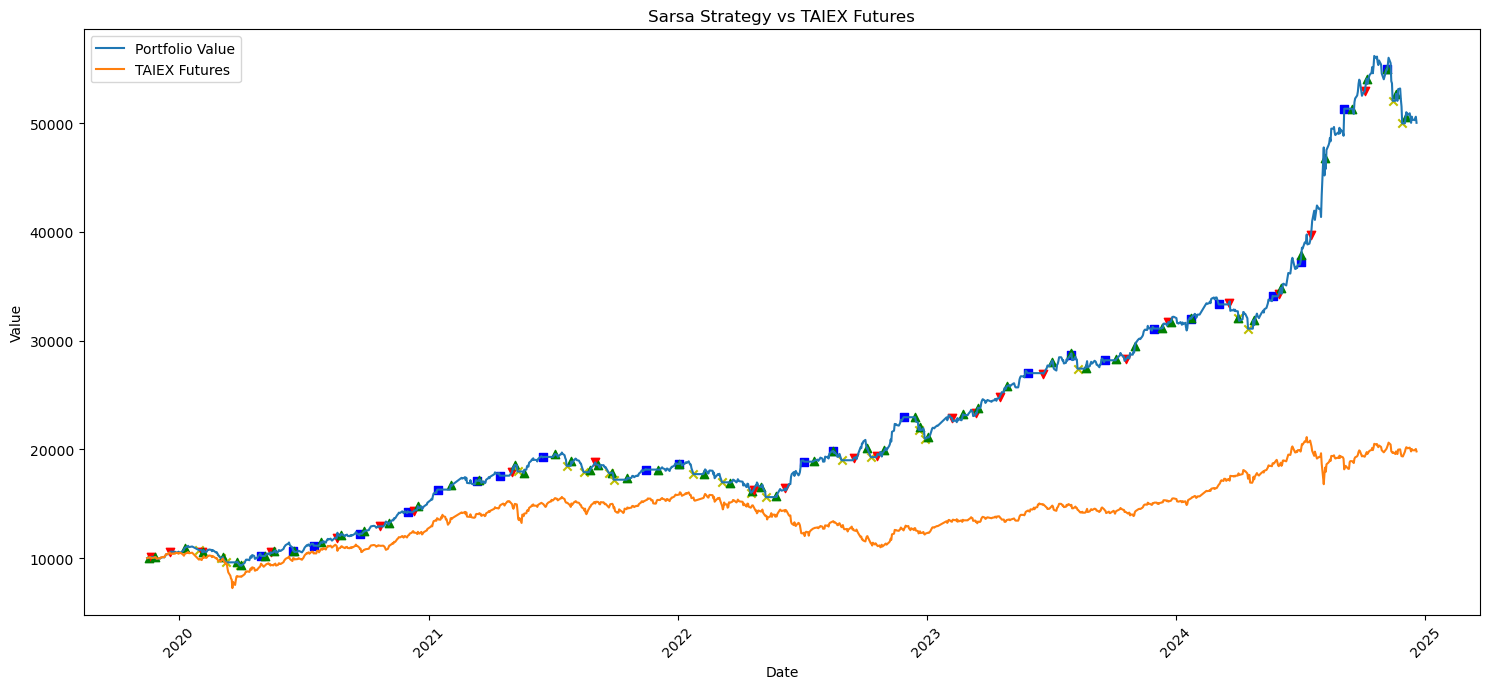


profit Performance Metrics:
Total Return (%): 400.3601
Annualized Return (%): 38.7114
Sharpe Ratio: 2.0382
Max Drawdown (%): 20.8002
Win Rate (%): 46.6935

訓練 winrate 模型:


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [11:15<00:00,  1.48it/s]


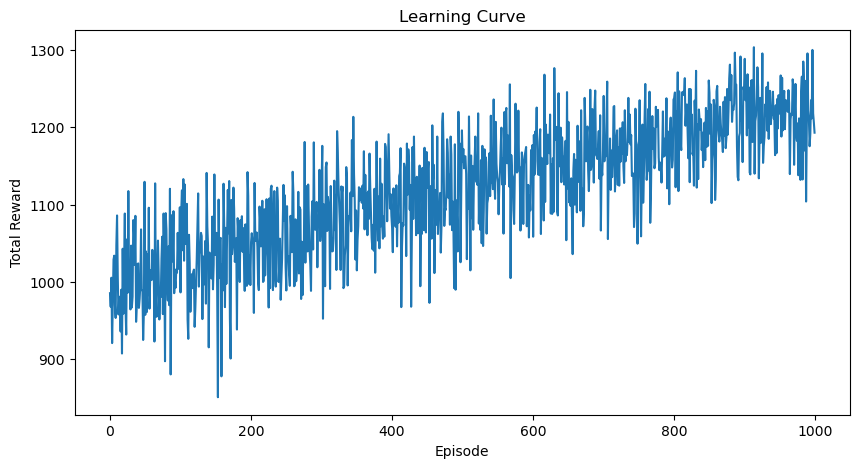


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-18 00:00:00	Buy		11593.00		Enter Long
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-05 00:00:00	Buy		11598.00		Enter Long
2020-01-03 00:00:00	TimeExit		12086.00		Exit Long
2020-01-06 00:00:00	Sell		11950.00		Enter Short
2020-01-10 00:00:00	Buy		12010.00		Enter Long
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-01-20 00:00:00	Buy		12111.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-04 00:00:00	Sell		11534.00		Enter Short
2020-02-14 00:00:00	Buy		11812.00		Enter Long
2020-02-18 00:00:00	Sell		11640.00		Enter Short
2020-02-19 00:00:00	Buy		11760.00		Enter Long
2020-02-20 00:00:00	Sell		11715.00		Enter Short
2020-03-20 00:00:00	TimeExit		9013.00		Exit Short
2020-04-01 00:00:00	Sell		9552.00		Enter Short
2020-04-06 00:00:00	StopLoss		9860.00		Exit Short
2020-04-06 00:00:00	Buy		9826.00		Enter Long
2020-05-04 00:00:00	Sell		10615.00		Enter Short
20

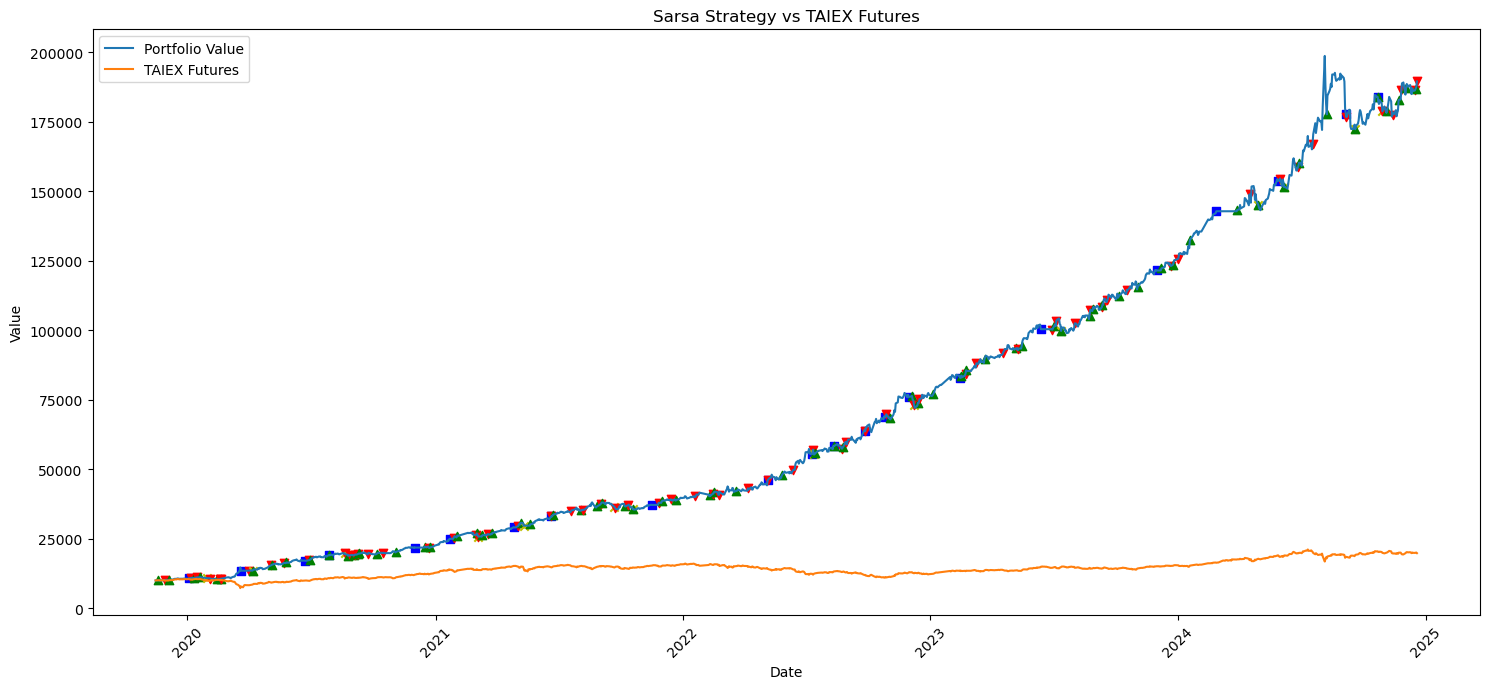


winrate Performance Metrics:
Total Return (%): 1794.5063
Annualized Return (%): 81.8110
Sharpe Ratio: 3.2866
Max Drawdown (%): 13.2764
Win Rate (%): 55.0000

訓練 sharpe 模型:


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [11:12<00:00,  1.49it/s]


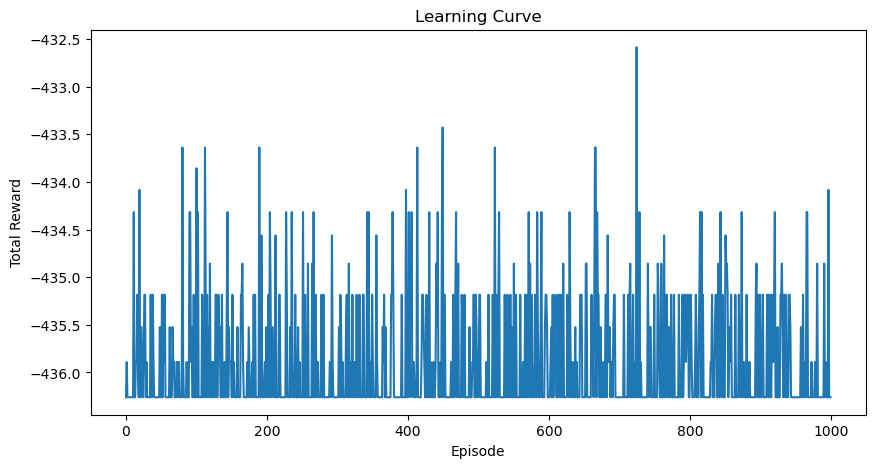


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-25 00:00:00	Sell		11565.00		Enter Short
2019-12-13 00:00:00	StopLoss		12007.00		Exit Short
2019-12-19 00:00:00	Sell		12030.00		Enter Short
2020-01-09 00:00:00	Buy		11968.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-05 00:00:00	Buy		11542.00		Enter Long
2020-03-02 00:00:00	StopLoss		11005.00		Exit Long
2020-03-05 00:00:00	Buy		11492.00		Enter Long
2020-03-09 00:00:00	StopLoss		10916.00		Exit Long
2020-03-24 00:00:00	Buy		9193.00		Enter Long
2020-04-13 00:00:00	Sell		10073.00		Enter Short
2020-04-15 00:00:00	StopLoss		10463.00		Exit Short
2020-05-14 00:00:00	Sell		10750.00		Enter Short
2020-05-28 00:00:00	StopLoss		11077.00		Exit Short
2020-06-23 00:00:00	Buy		11455.00		Enter Long
2020-06-29 00:00:00	Sell		11361.00		Enter Short
2020-07-02 00:00:00	StopLoss		11712.00		Exit Short
2020-07-10 00:00:00	Sell		11999.00		Enter Short
2020-07-22 00:00:00	StopLoss		12361

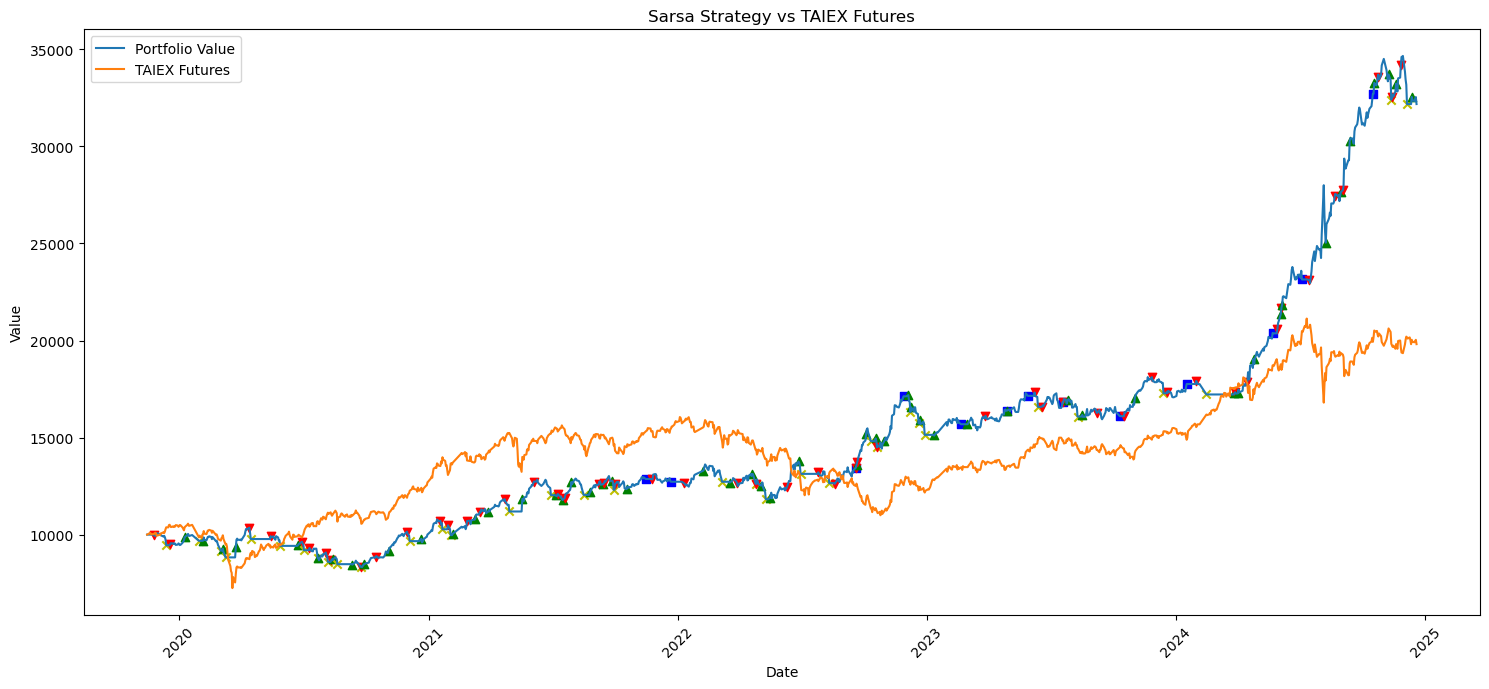


sharpe Performance Metrics:
Total Return (%): 221.8356
Annualized Return (%): 26.8132
Sharpe Ratio: 1.4331
Max Drawdown (%): 19.5850
Win Rate (%): 42.7419


In [53]:

def calculate_reward_profit_focused(action, row, position, holding_days):
    # 最大化獲利的獎勵函數
    return_value = row['Return']
    
    # 基本報酬
    base_reward = 5.0 * return_value if (action == "Buy" and position == "Long") or \
                                      (action == "Sell" and position == "Short") else 0
    
    # 持有時間獎勵
    holding_reward = 0.001 * holding_days if base_reward > 0 else 0
    
    # 基差獎勵
    basis_reward = 0.002 if (action == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                          (action == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    return base_reward + holding_reward + basis_reward

def calculate_reward_winrate_focused(action, row, position, holding_days):
    return_value = row['Return']
    
    # 基本報酬
    if position == "Long":
        base_reward = 1.0 if return_value > 0 else -1.0
    elif position == "Short":
        base_reward = 1.0 if return_value < 0 else -1.0
    else:
        base_reward = 0
    
    # 趨勢配合獎勵
    trend_reward = 0.5 if (action == "Buy" and row['MA5'] > row['MA20']) or \
                         (action == "Sell" and row['MA5'] < row['MA20']) else 0
    
    # 基差配合獎勵
    basis_reward = 0.5 if (action == "Buy" and row['Basis_Z_Score'] < -1) or \
                         (action == "Sell" and row['Basis_Z_Score'] > 1) else 0
    
    return base_reward + trend_reward + basis_reward

def calculate_reward_sharpe_focused(action, row, position, holding_days):
    return_value = row['Return']
    volatility = row['Volatility']
    
    # 風險調整後報酬
    if volatility == 0:
        risk_adjusted_return = 0
    else:
        risk_adjusted_return = return_value / volatility
    
    base_reward = 3.0 * risk_adjusted_return if position != "Cash" else 0
    
    # 波動率懲罰
    volatility_penalty = -0.001 * volatility if position != "Cash" else 0
    
    # 基差獎勵
    basis_reward = 0.001 if abs(row['Basis_Z_Score']) < 1.5 else -0.001
    
    return base_reward + volatility_penalty + basis_reward

def run_sarsa(data, thresholds, reward_function, episodes=1000):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"])
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], thresholds)
        action = agent.get_action(state)
        episode_reward = 0
        holding_days = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            if action == "Buy" and position != "Long":
                position = "Long"
                holding_days = 0
            elif action == "Sell" and position != "Short":
                position = "Short"
                holding_days = 0
            
            reward = reward_function(action, row, position, holding_days)
            episode_reward += reward
            
            next_state = define_state(row, thresholds)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, thresholds, initial_capital=10000, stop_loss=0.03):
    position = "Cash"
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    max_holding_days = 20
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, thresholds)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days:
            if position != "Cash":
                trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
                position = "Cash"
                portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
                holding_days = 0
        
        # 加入基差和技術指標的交易條件
        if action == "Buy" and position != "Long":
            if (row['Close'] > row['MA5']) and \
               (row['RSI'] < 70) and \
               (abs(row['Basis_Z_Score']) < 2):
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
                
        elif action == "Sell" and position != "Short":
            if (row['Close'] < row['MA5']) and \
               (row['RSI'] > 30) and \
               (abs(row['Basis_Z_Score']) < 2):
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def print_trade_details(trades):
    print("\n交易明細:")
    print("時間\t\t\t類型\t\t價格\t\t說明")
    print("-" * 70)
    for trade in trades:
        print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

# 主程序
if __name__ == "__main__":
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        thresholds = {
            'ma': 0.001,
            'rsi': 70,
        }
        
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 使用不同的獎勵函數訓練模型
        reward_functions = {
            'profit': calculate_reward_profit_focused,
            'winrate': calculate_reward_winrate_focused,
            'sharpe': calculate_reward_sharpe_focused
        }

        results = {}
        for name, reward_function in reward_functions.items():
            print(f"\n訓練 {name} 模型:")
            trained_agent, rewards_history = run_sarsa(train_data, thresholds, reward_function)
            plot_learning_curve(rewards_history)
            
            portfolio_values, trades = evaluate_strategy(trained_agent, test_data, thresholds)
            print_trade_details(trades)
            plot_results(test_data, portfolio_values, trades)
            
            benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
            performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
            
            results[name] = {
                'portfolio_values': portfolio_values,
                'trades': trades,
                'metrics': performance_metrics
            }
            
            print(f"\n{name} Performance Metrics:")
            for key, value in performance_metrics.items():
                print(f"{key}: {value:.4f}")
    else:
        print("Failed to read or preprocess the data.")



In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

class SarsaAgent:
    def __init__(self, actions, strategy_type='profit'):
        # 根據策略類型調整參數
        if strategy_type == 'profit':
            self.epsilon = 0.3
            self.alpha = 0.2
            self.gamma = 0.8
        elif strategy_type == 'winrate':
            self.epsilon = 0.4
            self.alpha = 0.3
            self.gamma = 0.7
        else:  # sharpe
            self.epsilon = 0.2
            self.alpha = 0.1
            self.gamma = 0.9
            
        self.epsilon_decay = 0.995
        self.actions = actions
        self.q_table = defaultdict(lambda: defaultdict(float))
        
    def get_action(self, state):
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            q_values = [self.q_table[state][a] for a in self.actions]
            return self.actions[np.argmax(q_values)]

    def learn(self, state, action, reward, next_state, next_action):
        current_q = self.q_table[state][action]
        next_q = self.q_table[next_state][next_action]
        new_q = current_q + self.alpha * (reward + self.gamma * next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon *= self.epsilon_decay

def calculate_atr(df, period=14):
    tr = pd.DataFrame()
    tr['h-l'] = df['High'] - df['Low']
    tr['h-pc'] = abs(df['High'] - df['Close'].shift(1))
    tr['l-pc'] = abs(df['Low'] - df['Close'].shift(1))
    tr['tr'] = tr[['h-l', 'h-pc', 'l-pc']].max(axis=1)
    return tr['tr'].rolling(period).mean()

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def preprocess_data(file_path):
    df = pd.read_csv(file_path, thousands=',')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 基本計算
    df['Return'] = df['Close'].pct_change()
    
    # 移動平均
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(5)) / df['MA20'].shift(5)
    
    # 波動率相關
    df['Volatility'] = df['Close'].rolling(window=20).std()
    df['Volatility_MA'] = df['Volatility'].rolling(window=20).mean()
    df['ATR'] = calculate_atr(df)
    
    # RSI和MACD
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    # 基差分析
    df['Basis_MA20'] = df['Basis'].rolling(window=20).mean()
    df['Basis_STD'] = df['Basis'].rolling(window=20).std()
    df['Basis_Z_Score'] = (df['Basis'] - df['Basis_MA20']) / df['Basis_STD']
    df['Basis_Change'] = df['Basis'].diff()
    df['Basis_Momentum'] = df['Basis'] - df['Basis'].shift(5)
    
    # 趨勢強度
    df['Trend_Strength'] = abs(df['MA5'] - df['MA20']) / df['MA20']
    
    df = df.dropna()
    return df

def define_state(row, thresholds):
    # 趨勢方向
    if row['Close'] > row['MA20'] and row['MA5'] > row['MA20']:
        trend_state = "Strong_Up"
    elif row['Close'] > row['MA20']:
        trend_state = "Weak_Up"
    elif row['Close'] < row['MA20'] and row['MA5'] < row['MA20']:
        trend_state = "Strong_Down"
    else:
        trend_state = "Weak_Down"
    
    # RSI狀態
    if row['RSI'] > 70:
        rsi_state = "OverBought"
    elif row['RSI'] < 30:
        rsi_state = "OverSold"
    else:
        rsi_state = "Normal"
    
    # 基差狀態
    if abs(row['Basis_Z_Score']) > 2:
        basis_state = "Extreme"
    elif abs(row['Basis_Z_Score']) > 1.5:
        basis_state = "Wide"
    else:
        basis_state = "Normal"
    
    # 波動率狀態
    vol_state = "High" if row['Volatility'] > row['Volatility_MA'] else "Low"
    
    return f"{trend_state}_{rsi_state}_{basis_state}_{vol_state}"


資料集大小:
總資料筆數: 4135
訓練資料筆數: 2894
測試資料筆數: 1241
--------------------------------------------------

訓練 profit 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [12:22<00:00,  1.35it/s]


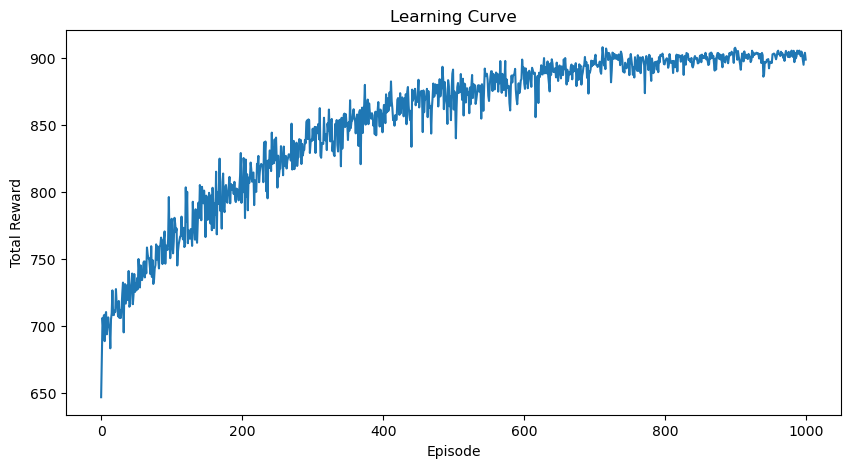


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-18 00:00:00	Buy		11593.00		Enter Long
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-09 00:00:00	Buy		11671.00		Enter Long
2020-01-07 00:00:00	TimeExit		11871.00		Exit Long
2020-01-20 00:00:00	Buy		12111.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-01-31 00:00:00	Sell		11468.00		Enter Short
2020-02-13 00:00:00	StopLoss		11837.00		Exit Short
2020-02-18 00:00:00	Sell		11640.00		Enter Short
2020-02-19 00:00:00	Buy		11760.00		Enter Long
2020-02-24 00:00:00	Sell		11508.00		Enter Short
2020-03-24 00:00:00	TimeExit		9193.00		Exit Short
2020-04-01 00:00:00	Sell		9552.00		Enter Short
2020-04-06 00:00:00	StopLoss		9860.00		Exit Short
2020-04-07 00:00:00	Buy		9997.00		Enter Long
2020-05-06 00:00:00	TimeExit		10750.00		Exit Long
2020-05-06 00:00:00	Buy		10750.00		Enter Long
2020-06-03 00:00:00	TimeExit		11283.00		Exit Long
2020-06-17 00:00:00	Buy		11521.00		Enter 

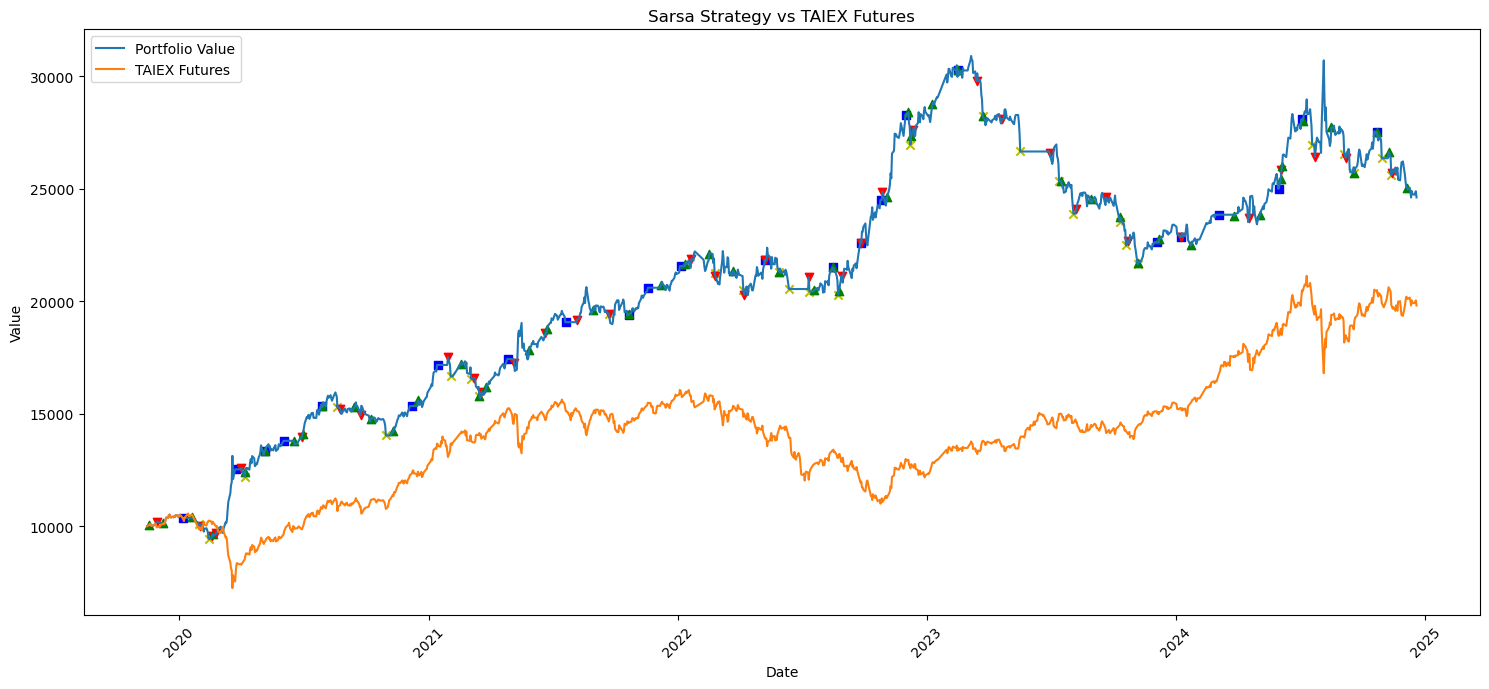


profit Performance Metrics:
Total Return (%): 146.1499
Annualized Return (%): 20.0886
Sharpe Ratio: 1.0502
Max Drawdown (%): 29.9500
Win Rate (%): 45.6452

訓練 winrate 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [10:51<00:00,  1.53it/s]


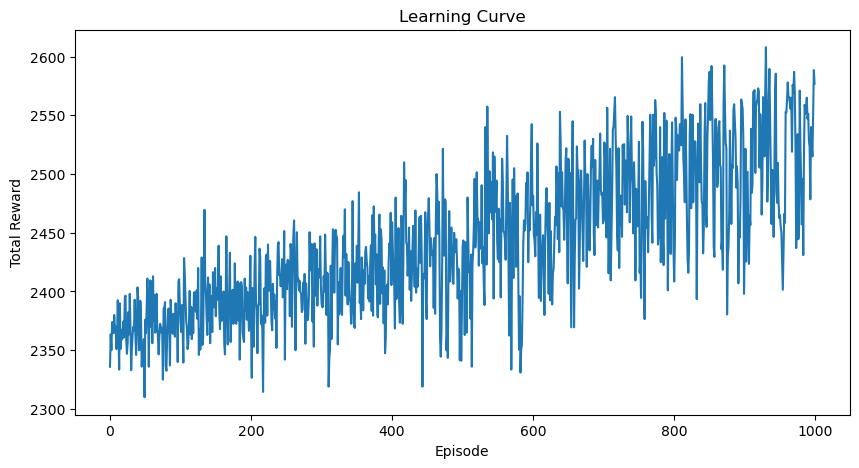


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-18 00:00:00	Buy		11593.00		Enter Long
2019-12-02 00:00:00	Sell		11502.00		Enter Short
2019-12-05 00:00:00	Buy		11598.00		Enter Long
2019-12-19 00:00:00	Sell		12030.00		Enter Short
2020-01-10 00:00:00	TimeExit		12010.00		Exit Short
2020-01-10 00:00:00	Buy		12010.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-21 00:00:00	Sell		11664.00		Enter Short
2020-03-16 00:00:00	TimeExit		9668.00		Exit Short
2020-03-24 00:00:00	Buy		9193.00		Enter Long
2020-04-13 00:00:00	Sell		10073.00		Enter Short
2020-04-14 00:00:00	StopLoss		10355.00		Exit Short
2020-04-27 00:00:00	Buy		10547.00		Enter Long
2020-05-12 00:00:00	Sell		10865.00		Enter Short
2020-05-19 00:00:00	Buy		10872.00		Enter Long
2020-05-22 00:00:00	Sell		10743.00		Enter Short
2020-05-26 00:00:00	StopLoss		11027.00		Exit Short
2020-05-26 00:00:00	Buy		10984.00		Enter Long
2020-06-11 00:00:00	Sell		11491.00		Enter Sh

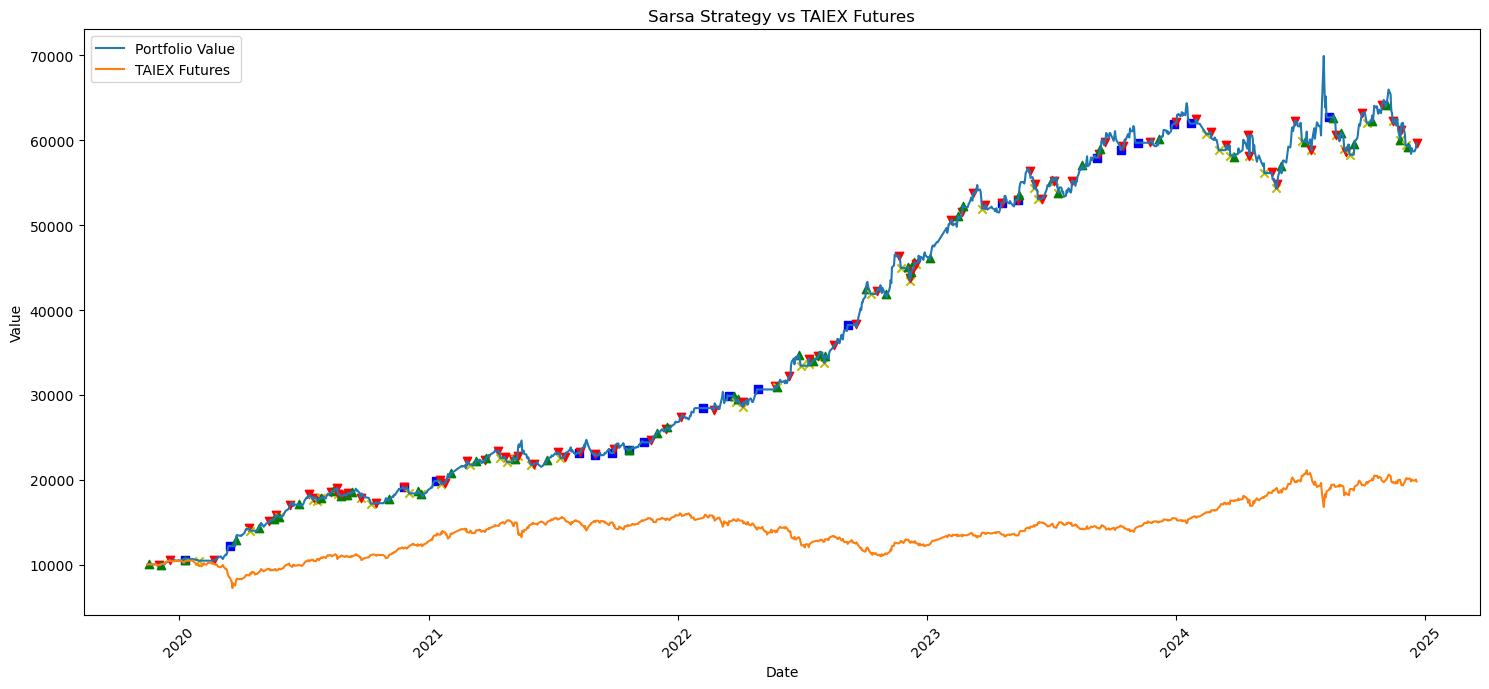


winrate Performance Metrics:
Total Return (%): 497.1144
Annualized Return (%): 43.7854
Sharpe Ratio: 2.1444
Max Drawdown (%): 16.6463
Win Rate (%): 47.0968

訓練 sharpe 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 1000/1000 [11:57<00:00,  1.39it/s]


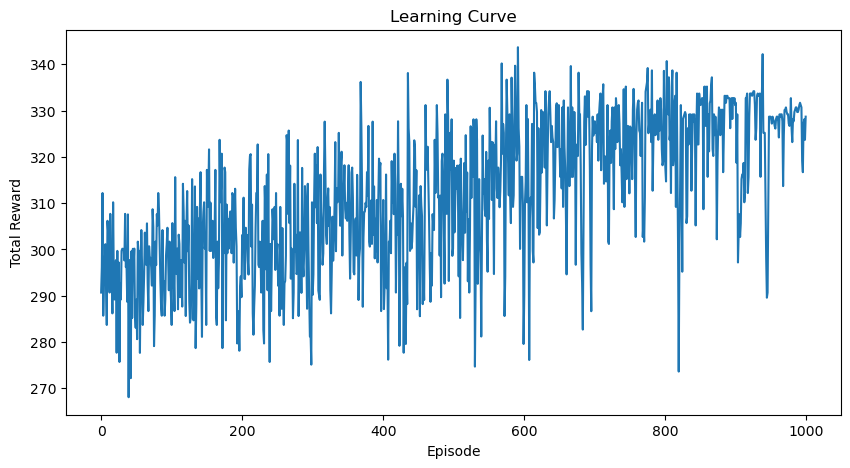


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-18 00:00:00	Buy		11593.00		Enter Long
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-05 00:00:00	Buy		11598.00		Enter Long
2019-12-19 00:00:00	TimeExit		12030.00		Exit Long
2019-12-19 00:00:00	Sell		12030.00		Enter Short
2020-01-03 00:00:00	TimeExit		12086.00		Exit Short
2020-01-09 00:00:00	Buy		11968.00		Enter Long
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-01-20 00:00:00	Buy		12111.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-20 00:00:00	Sell		11715.00		Enter Short
2020-03-04 00:00:00	Buy		11364.00		Enter Long
2020-03-09 00:00:00	StopLoss		10916.00		Exit Long
2020-04-07 00:00:00	Buy		9997.00		Enter Long
2020-04-21 00:00:00	TimeExit		10198.00		Exit Long
2020-04-27 00:00:00	Buy		10547.00		Enter Long
2020-05-04 00:00:00	Sell		10615.00		Enter Short
2020-05-05 00:00:00	StopLoss		10795.00		Exit Short
2020-05-05 00:00:00	Buy		10725.00		Enter Lo

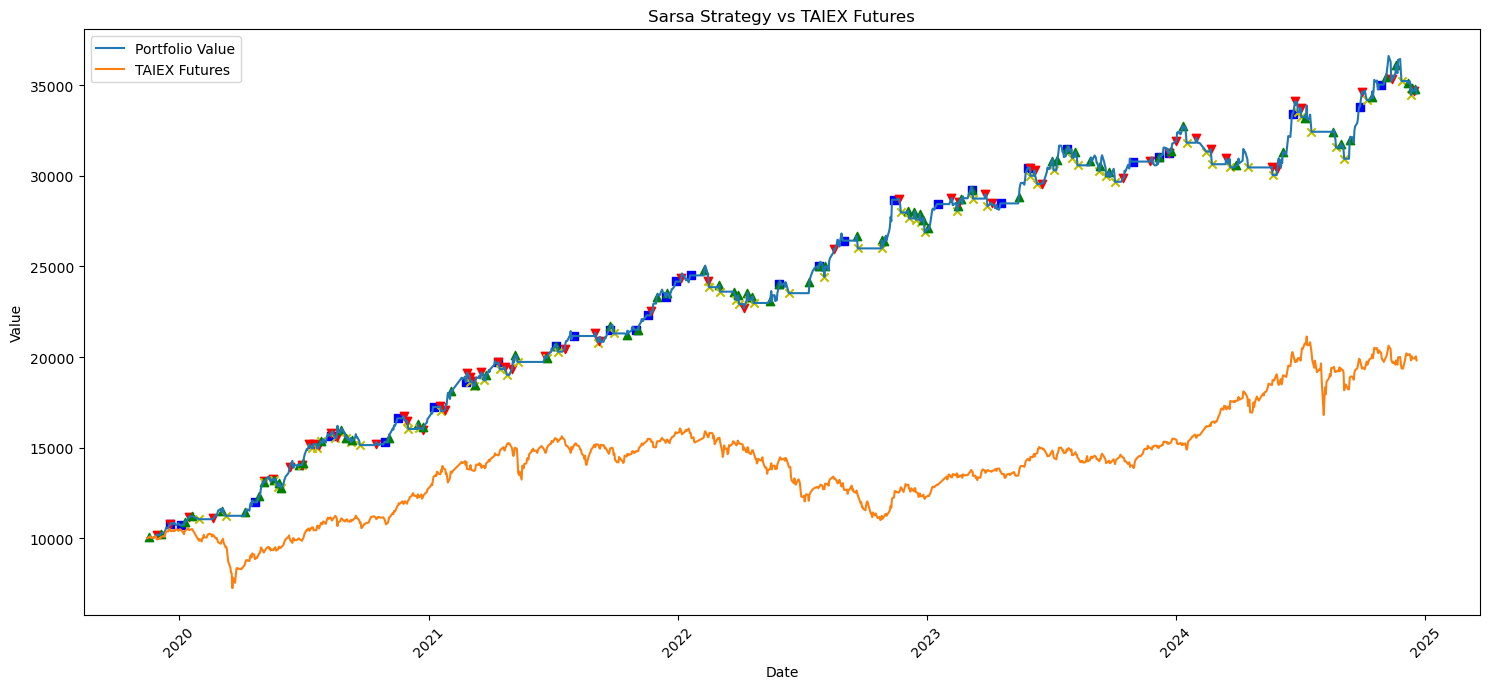


sharpe Performance Metrics:
Total Return (%): 245.3896
Annualized Return (%): 28.6466
Sharpe Ratio: 2.0672
Max Drawdown (%): 9.3981
Win Rate (%): 35.4839


In [63]:
def calculate_reward_profit_enhanced(action, row, position, holding_days):
    return_value = row['Return']
    
    # 基本報酬
    base_reward = 4.0 * return_value if position != "Cash" else 0
    
    # 趨勢獎勵
    trend_reward = 0.5 if (action == "Buy" and row['MA5'] > row['MA20'] and row['Basis_Z_Score'] < 0) or \
                        (action == "Sell" and row['MA5'] < row['MA20'] and row['Basis_Z_Score'] > 0) else 0
    
    # 持有時間獎勵
    holding_reward = 0.002 * holding_days if base_reward > 0 else 0
    
    # 基差獎勵
    basis_reward = 0.3 if (action == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                        (action == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    return base_reward + trend_reward + holding_reward + basis_reward

def calculate_reward_winrate_enhanced(action, row, position, holding_days):
    return_value = row['Return']
    
    # 基本獎勵
    if position != "Cash":
        base_reward = 2.0 if return_value > 0 else -1.0
    else:
        base_reward = 0
    
    # 基差配合獎勵
    basis_reward = 1.0 if (action == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                        (action == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    # 技術指標確認獎勵
    tech_reward = 0.5 if (action == "Buy" and row['RSI'] < 30) or \
                        (action == "Sell" and row['RSI'] > 70) else 0
    
    # 虧損控制獎勵
    loss_control = 0.3 if -0.01 <= return_value < 0 else 0
    
    return base_reward + basis_reward + tech_reward + loss_control

def calculate_reward_sharpe_enhanced(action, row, position, holding_days):
    return_value = row['Return']
    volatility = row['Volatility']
    
    # 風險調整後報酬
    risk_adjusted_return = return_value / (volatility ** 0.5) if volatility > 0 else 0
    base_reward = 3.0 * risk_adjusted_return if position != "Cash" else 0
    
    # 趨勢強度獎勵
    trend_reward = 0.5 * row['Trend_Strength'] if position != "Cash" else 0
    
    # 基差獎勵
    basis_reward = 0.5 if volatility < row['Volatility_MA'] and \
                        ((action == "Buy" and row['Basis_Z_Score'] < -1) or \
                         (action == "Sell" and row['Basis_Z_Score'] > 1)) else 0
    
    # 波動率獎勵
    vol_reward = 0.2 if volatility < row['Volatility_MA'] else -0.1
    
    return base_reward + trend_reward + basis_reward + vol_reward

def run_sarsa(data, thresholds, strategy_type='profit', episodes=1000):
    agent = SarsaAgent(actions=["Buy", "Sell", "Hold"], strategy_type=strategy_type)
    rewards_history = []
    
    # 選擇獎勵函數
    if strategy_type == 'profit':
        reward_function = calculate_reward_profit_enhanced
    elif strategy_type == 'winrate':
        reward_function = calculate_reward_winrate_enhanced
    else:
        reward_function = calculate_reward_sharpe_enhanced
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        position = "Cash"
        state = define_state(data.iloc[0], thresholds)
        action = agent.get_action(state)
        episode_reward = 0
        holding_days = 0
        
        for i in range(1, len(data)):
            row = data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            if action == "Buy" and position != "Long":
                position = "Long"
                holding_days = 0
            elif action == "Sell" and position != "Short":
                position = "Short"
                holding_days = 0
            
            reward = reward_function(action, row, position, holding_days)
            episode_reward += reward
            
            next_state = define_state(row, thresholds)
            next_action = agent.get_action(next_state)
            
            agent.learn(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
        
        rewards_history.append(episode_reward)
        agent.decay_epsilon()
    
    return agent, rewards_history

def evaluate_strategy(agent, data, thresholds, strategy_type='profit'):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 根據策略類型設定參數
    if strategy_type == 'profit':
        max_holding_days = 20
        stop_loss = 0.03
    elif strategy_type == 'winrate':
        max_holding_days = 15
        stop_loss = 0.02
    else:  # sharpe
        max_holding_days = 10
        stop_loss = 0.015
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row, thresholds)
        action = agent.get_action(state)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days:
            if position != "Cash":
                trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
                position = "Cash"
                if position == "Long":
                    portfolio_value *= (1 + return_value)
                elif position == "Short":
                    portfolio_value *= (1 - return_value)
                holding_days = 0
        
        # 交易條件
        if action == "Buy" and position != "Long":
            if (row['Close'] > row['MA5'] and 
                abs(row['Basis_Z_Score']) < 2 and 
                row['RSI'] < 70):
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
                
        elif action == "Sell" and position != "Short":
            if (row['Close'] < row['MA5'] and 
                abs(row['Basis_Z_Score']) < 2 and 
                row['RSI'] > 30):
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
    
    plt.title('Sarsa Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def print_trade_details(trades):
    print("\n交易明細:")
    print("時間\t\t\t類型\t\t價格\t\t說明")
    print("-" * 70)
    for trade in trades:
        print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        thresholds = {
            'ma': 0.001,
            'rsi': 70,
        }
        
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 測試不同策略
        strategy_types = ['profit', 'winrate', 'sharpe']
        results = {}
        
        for strategy in strategy_types:
            print(f"\n訓練 {strategy} 策略:")
            trained_agent, rewards_history = run_sarsa(train_data, thresholds, strategy)
            plot_learning_curve(rewards_history)
            
            portfolio_values, trades = evaluate_strategy(trained_agent, test_data, thresholds, strategy)
            print_trade_details(trades)
            plot_results(test_data, portfolio_values, trades)
            
            benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
            performance_metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
            
            print(f"\n{strategy} Performance Metrics:")
            for key, value in performance_metrics.items():
                print(f"{key}: {value:.4f}")
                
            results[strategy] = {
                'portfolio_values': portfolio_values,
                'trades': trades,
                'metrics': performance_metrics
            }